In [1]:
# Import packages
from pathlib import Path

PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
ANALYSIS_NAME = "Analysis_2"
INDEX_DIR = PROJECT_DIR / "Index" / "mouse"
ANALYSIS_DIR = Path.cwd()
LOGCPM_TRANSFORM = True
CUTOFFS = [300, 300, 300, 300]
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons_standard.csv")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics', type='standard')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
# plotting.upsample(raw_datasets, Path("preseq/standard"), overwrite=False)
# plotting.plot_upsample(raw_datasets, Path("preseq/standard"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

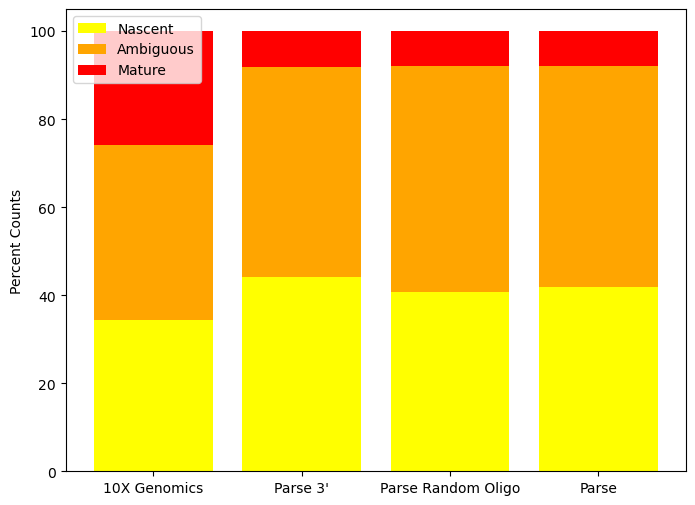

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

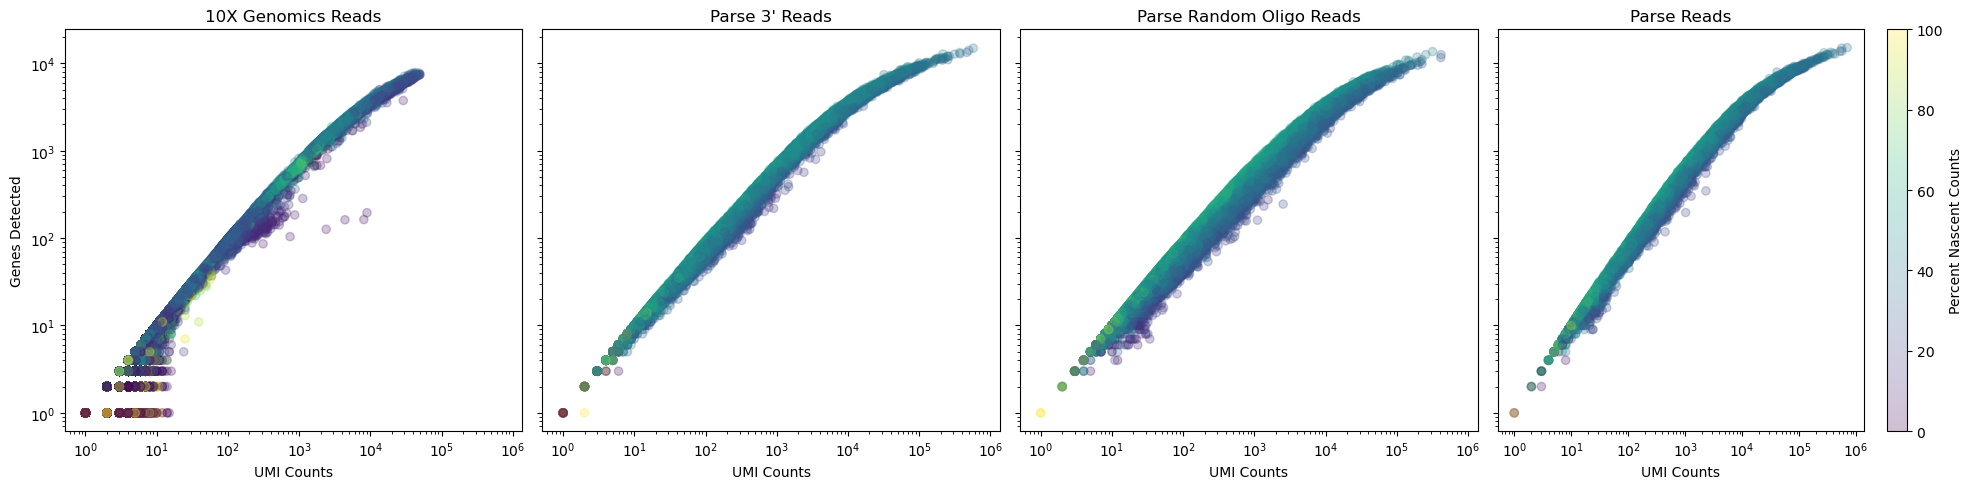

In [8]:
plotting.scatter_reads(raw_datasets)

In [9]:
# Path to save gene metadata so don't need to query Ensembl
# more than once
gene_info = plotting.query_ensembl(ANALYSIS_DIR, index_dir=INDEX_DIR, overwrite=True)

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


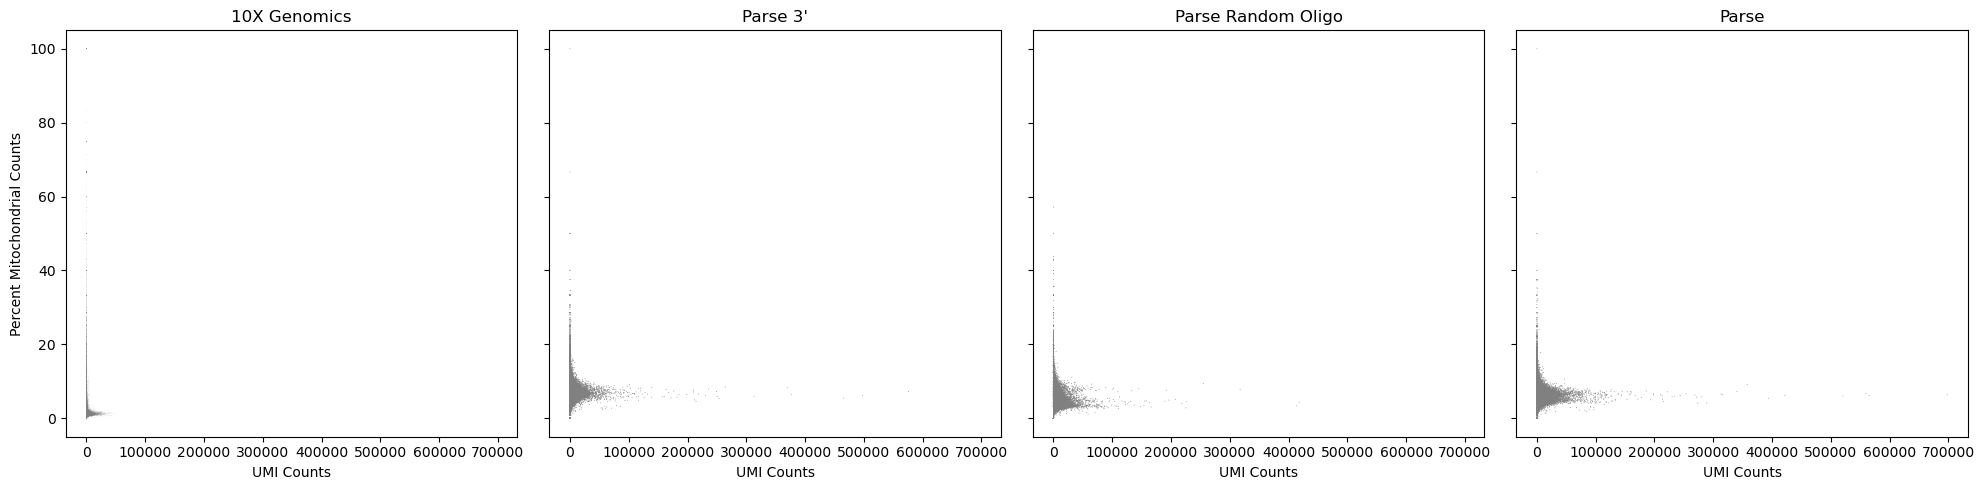

In [11]:
plotting.mito_scatter(raw_datasets)

14,462 cells passed the 300 UMI threshold for 10X Genomics
Applied CPM normalization and log1p transformation to the filtered data.
36,902 cells passed the 300 UMI threshold for Parse 3'
Applied CPM normalization and log1p transformation to the filtered data.
32,758 cells passed the 300 UMI threshold for Parse Random Oligo
Applied CPM normalization and log1p transformation to the filtered data.
38,866 cells passed the 300 UMI threshold for Parse
Applied CPM normalization and log1p transformation to the filtered data.


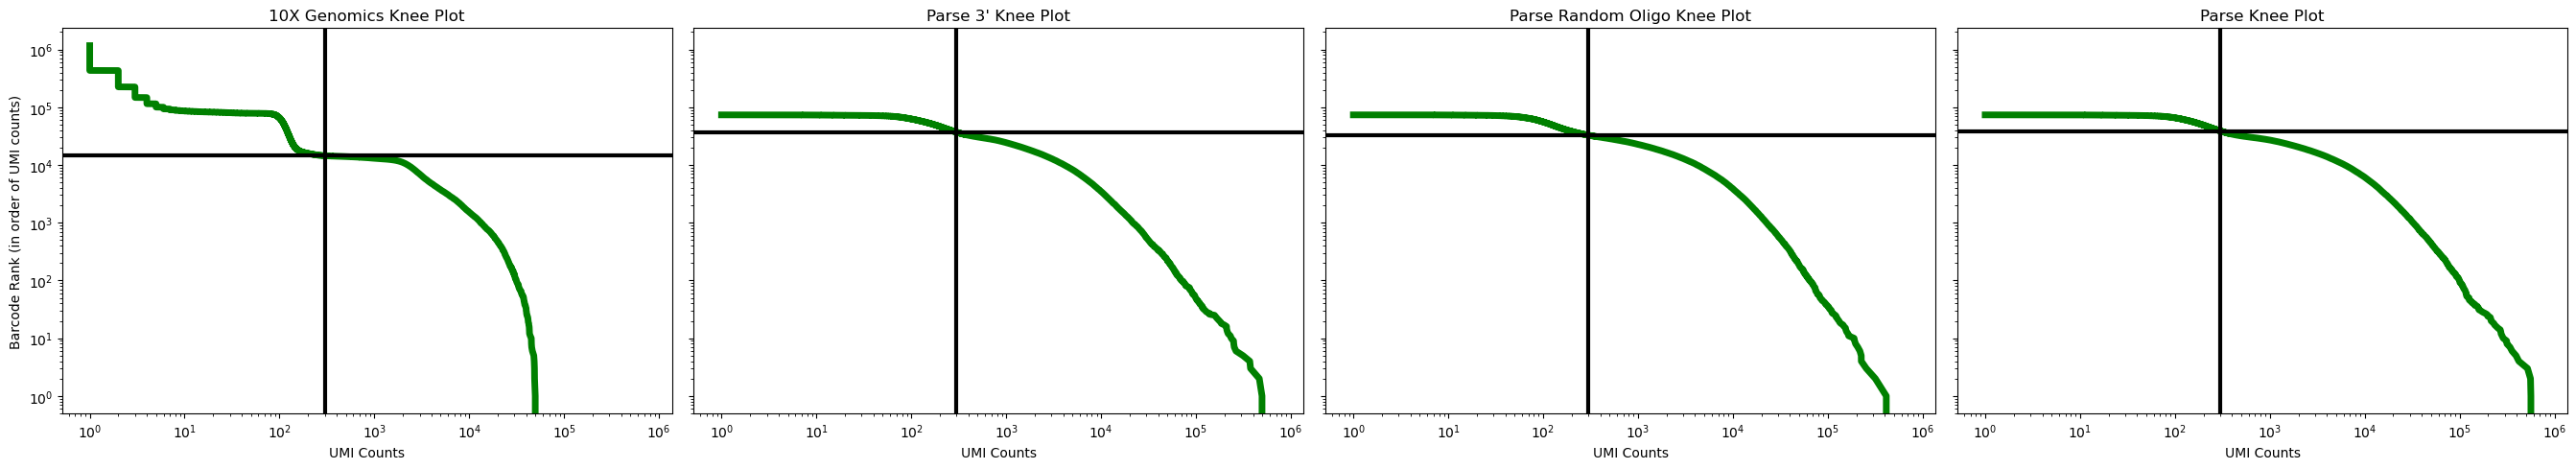

In [12]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS, transform=LOGCPM_TRANSFORM)

In [13]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

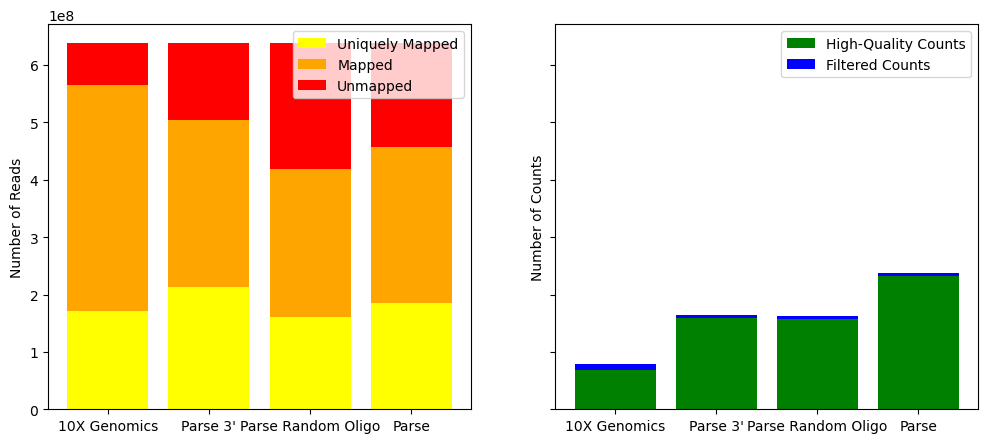

In [14]:
plotting.plot_filtering_metrics(datasets)

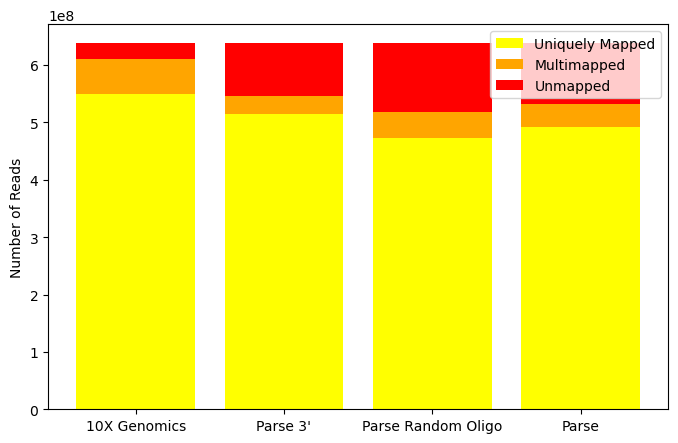

In [15]:
plotting.plot_filtering_metrics_star(datasets)

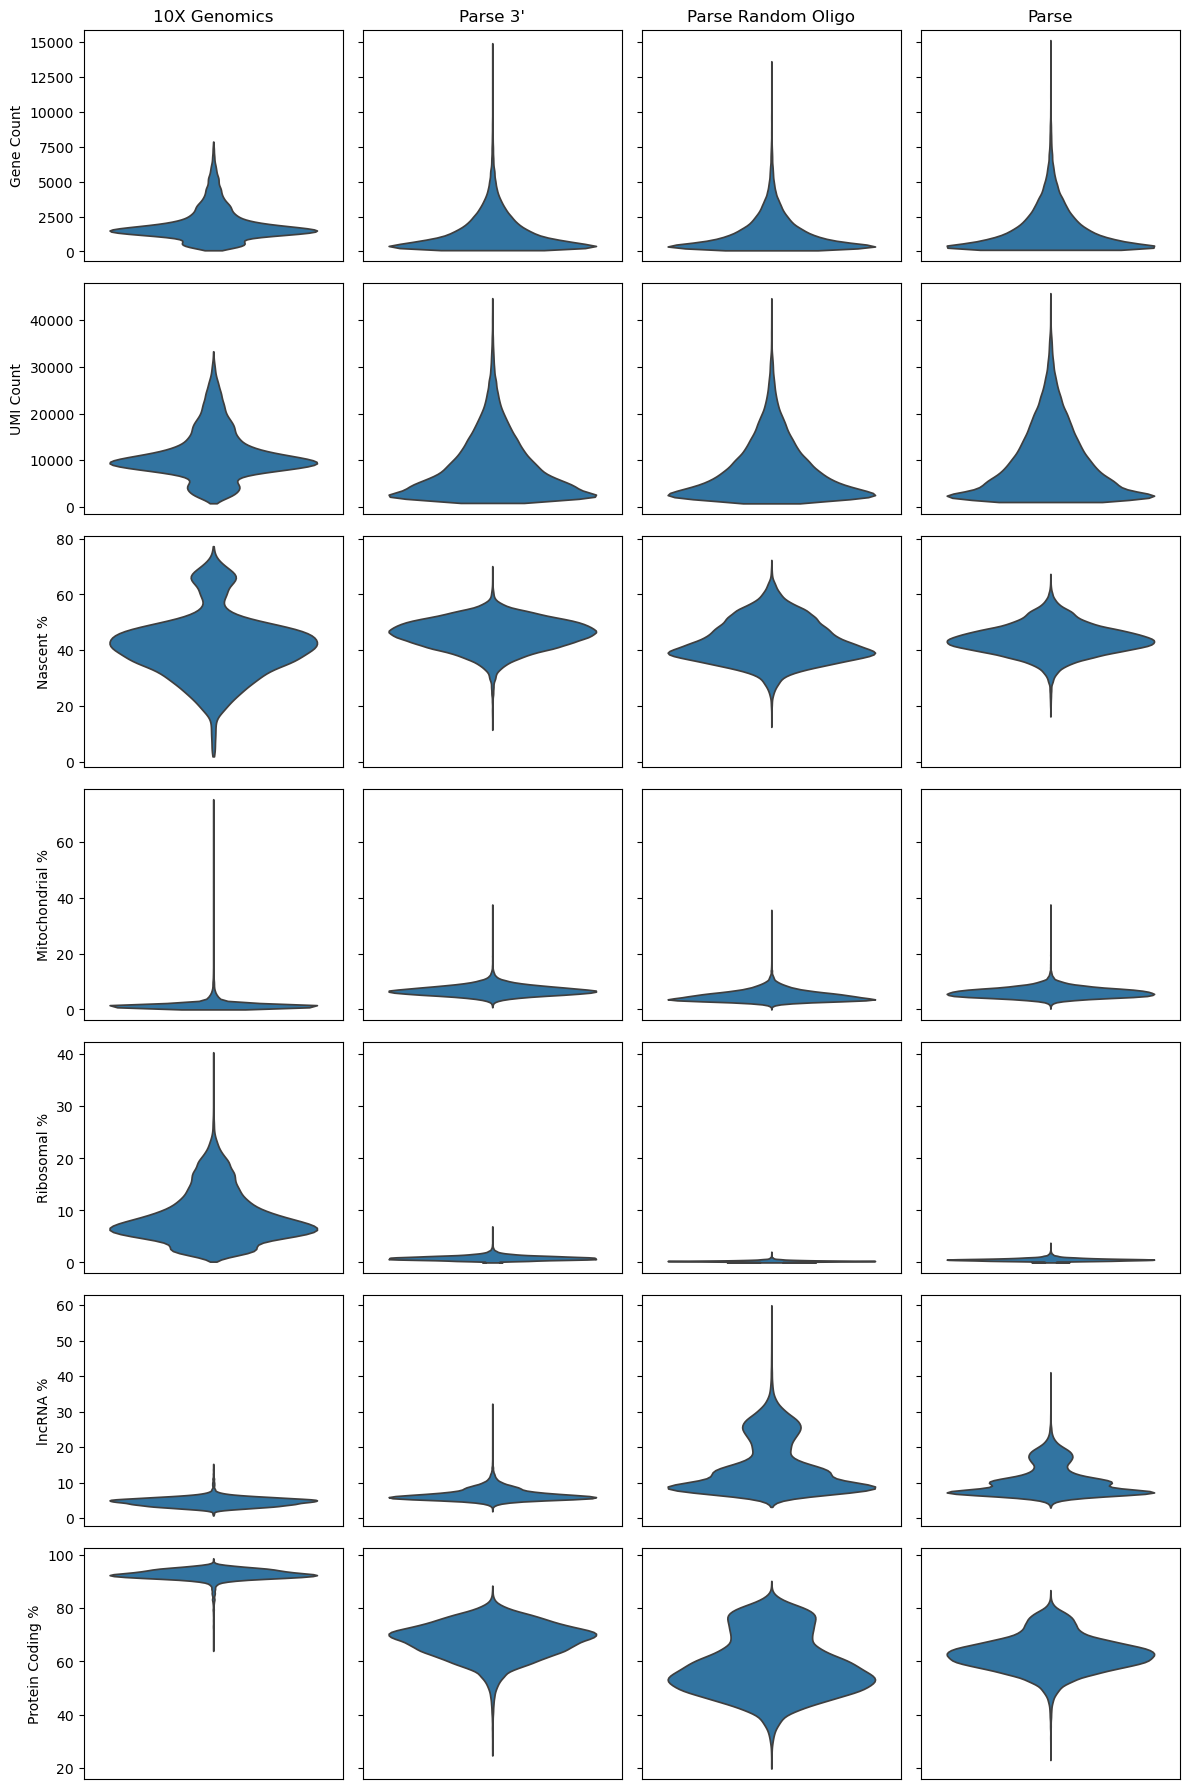

In [16]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

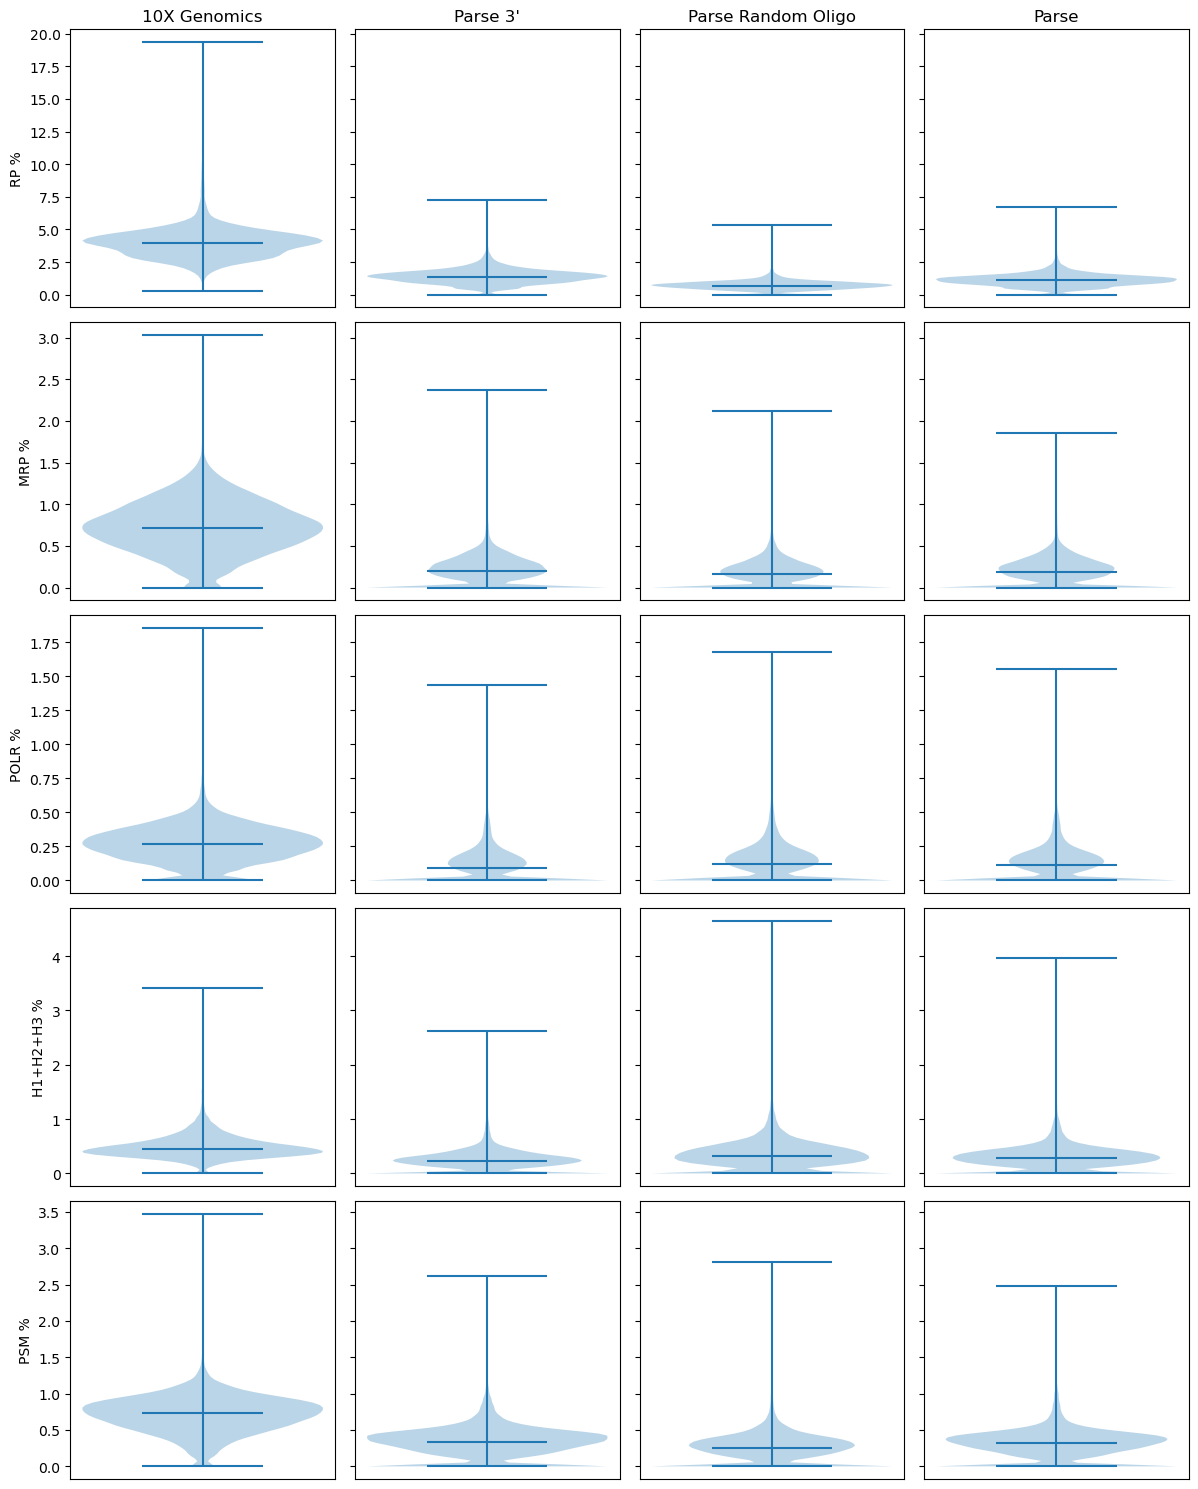

In [17]:
# Transcritptional Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["RP", "MRP", "POLR", "H1+H2+H3", "PSM"])

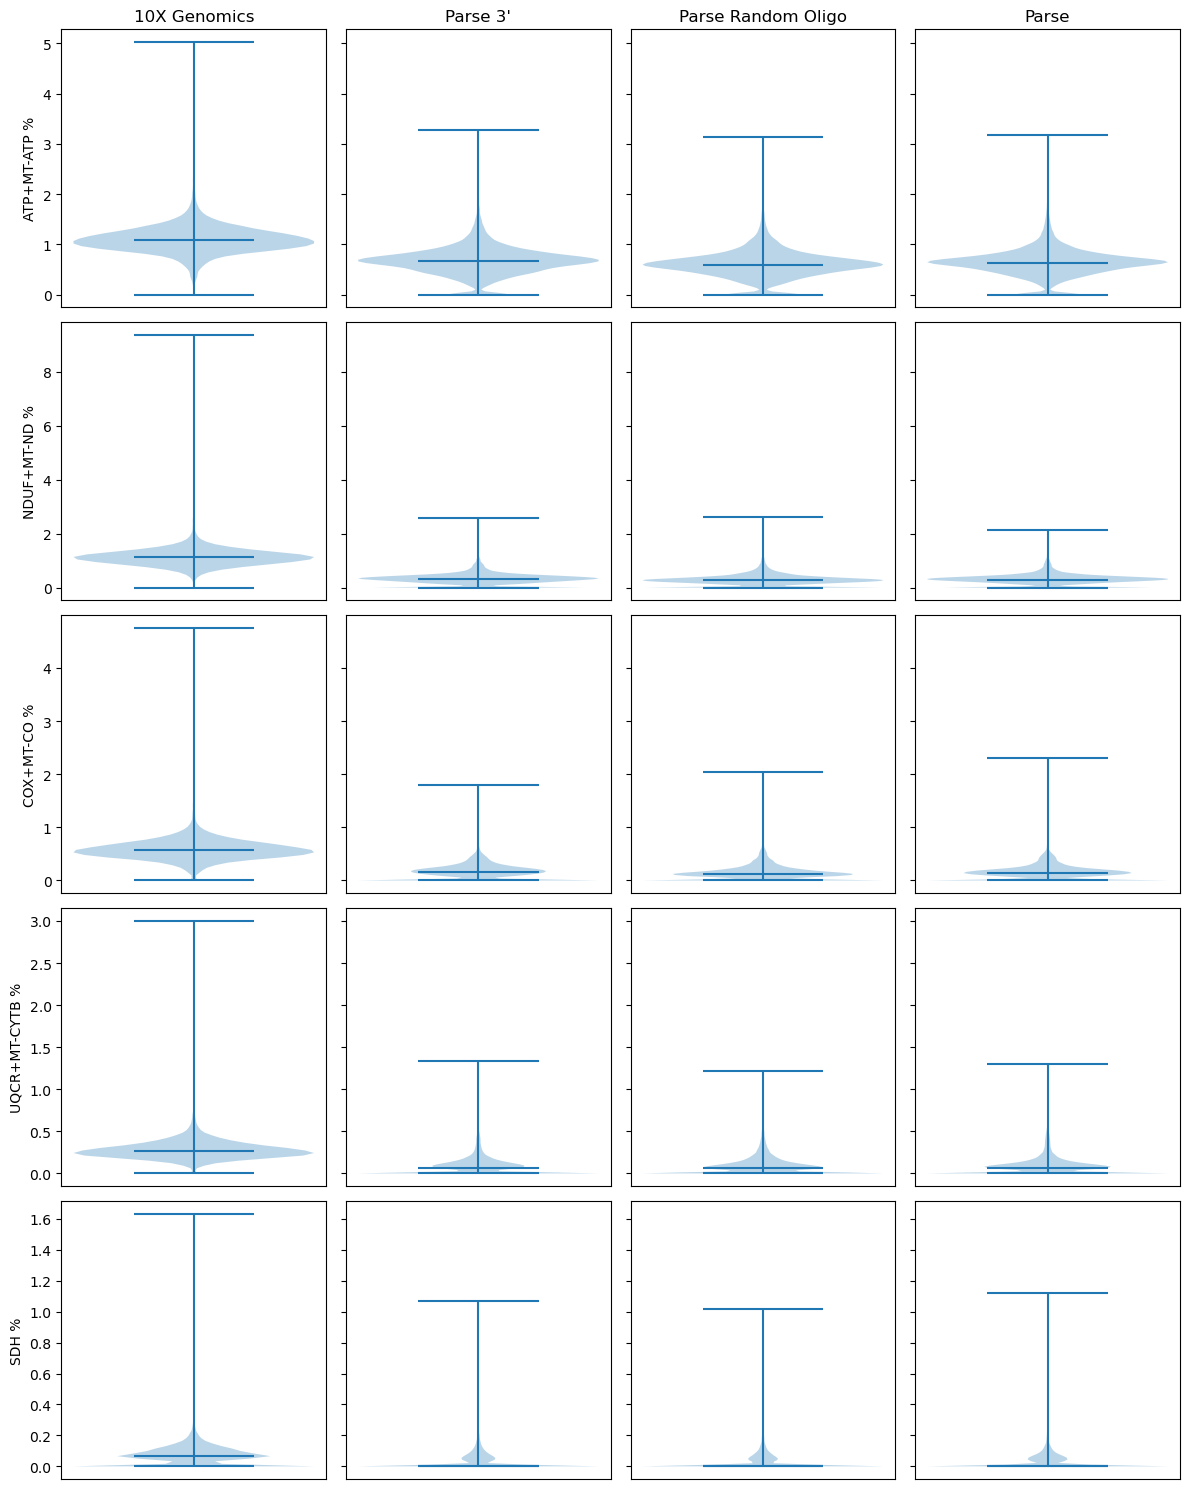

In [18]:
# OXPHOS Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ATP+MT-ATP", "NDUF+MT-ND", "COX+MT-CO", "UQCR+MT-CYTB", "SDH"])

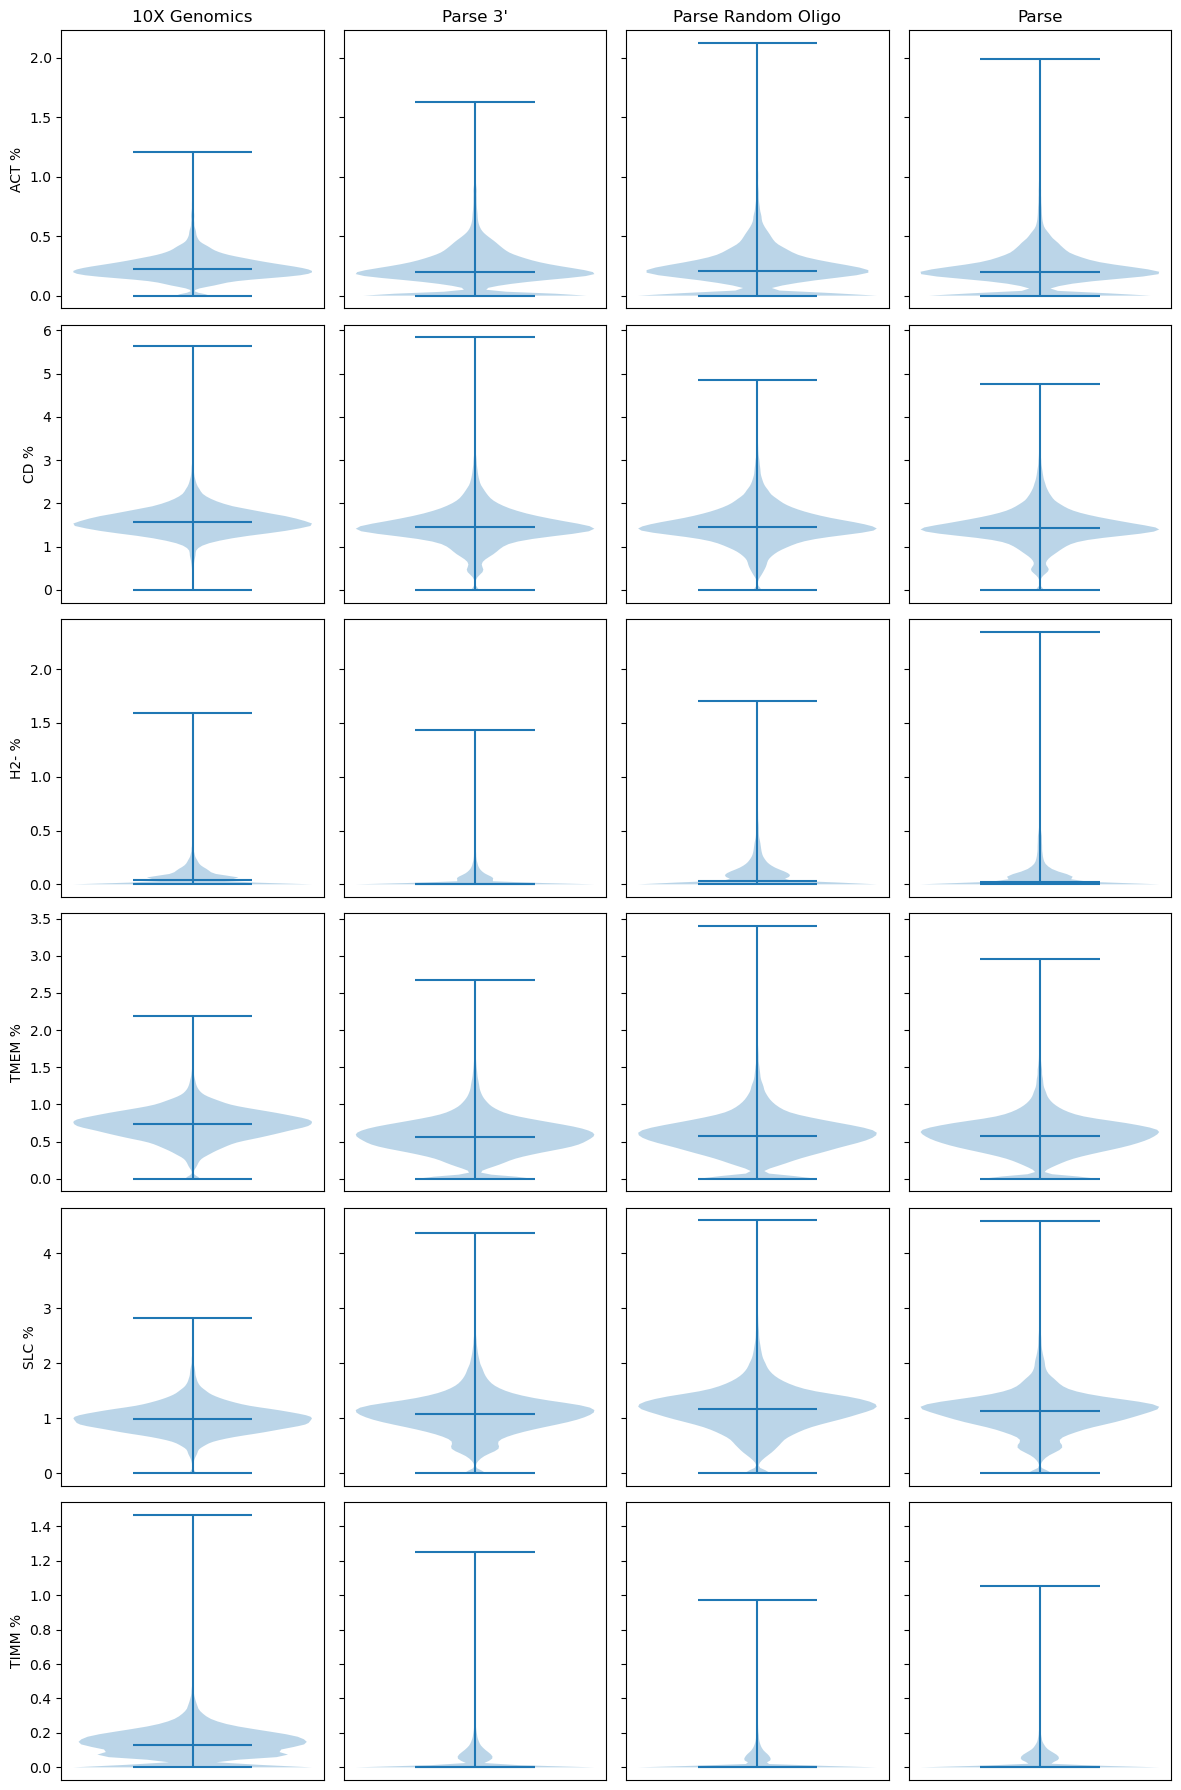

In [19]:
# cell suface and transmembrane protein gene family percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ACT", "CD", "H2-", "TMEM", "SLC", "TIMM"])

# Read/Gene Comparisons

In [20]:
# Pan-leukocyte anchor
pan_leukocyte = ["Ptprc"]

# Early thymic progenitor & T-lineage commitment (ETP / DN1–DN2)
early_progenitor_commitment = ["Kit", "Cd44", "Bcl11b", "Tcf7", "Gata3"]

# Rearrangement & β-selection (DN3–DN4)
rearrangement_beta_selection = ["Il2ra", "Rag1", "Rag2", "Ptcra", "Dntt"]

# Proliferation
proliferation = ["Mki67"]

# DP identity & TCR/CD3
dp_identity = ["Cd4", "Cd8a", "Cd8b1", "Cd24a", "Cd3e", "Cd3d", "Cd3g"]

# Positive selection & TCR signal strength
positive_selection_signal = ["Themis", "Cd69", "Cd5", "Cd28", "Nr4a1"]

# CD4 vs CD8 lineage commitment
lineage_commitment = ["Zbtb7b", "Runx3"]

# SP maturation & thymic egress
sp_maturation_egress = ["Ccr9", "Ccr7", "Sell", "Klf2", "S1pr1"]

# Regulatory T cells
treg = ["Foxp3"]

# Survival / negative-selection axis
survival_negative_selection = ["Bcl2", "Bcl2l11"]

# γδ / innate-like lineage
gd_innate = ["Zbtb16"]

# Stromal & myeloid contamination flags (QC) — NOT thymocyte-intrinsic
qc_stromal_myeloid = ["Aire", "Krt5", "Krt8", "Krt18", "Lyz2"] #"Krt14"

thymocyte_markers = {
    "Pan Leukocyte": pan_leukocyte,
    "Early Progenitor Commitment": early_progenitor_commitment,
    "Rearrangement/Beta Selection": rearrangement_beta_selection,
    "Proliferation": proliferation,
    "DP Identity": dp_identity,
    "Positive Selection Signal": positive_selection_signal,
    "Lineage Commitment": lineage_commitment,
    "SP Maturation Egress": sp_maturation_egress,
    "Treg": treg,
    "Survival Negative Selection": survival_negative_selection,
    "GD Innate": gd_innate,
    "Stromal/Myeloid QC": qc_stromal_myeloid,
}

# TCR loci — PREFIXES (match by startswith, not exact)
tcr_loci_prefixes = ["Trav", "Trbv", "Trgv", "Trdv"]

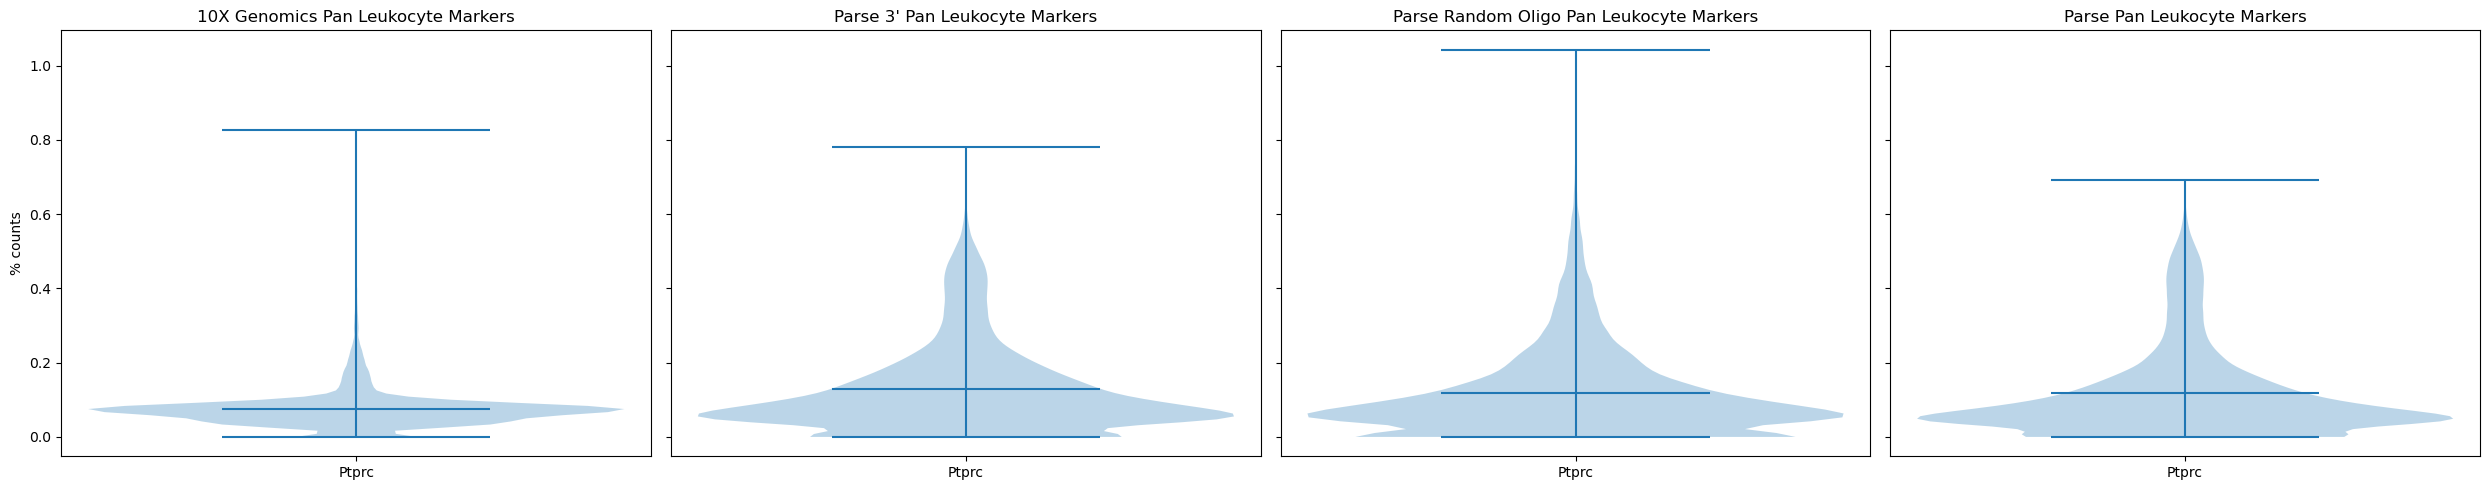

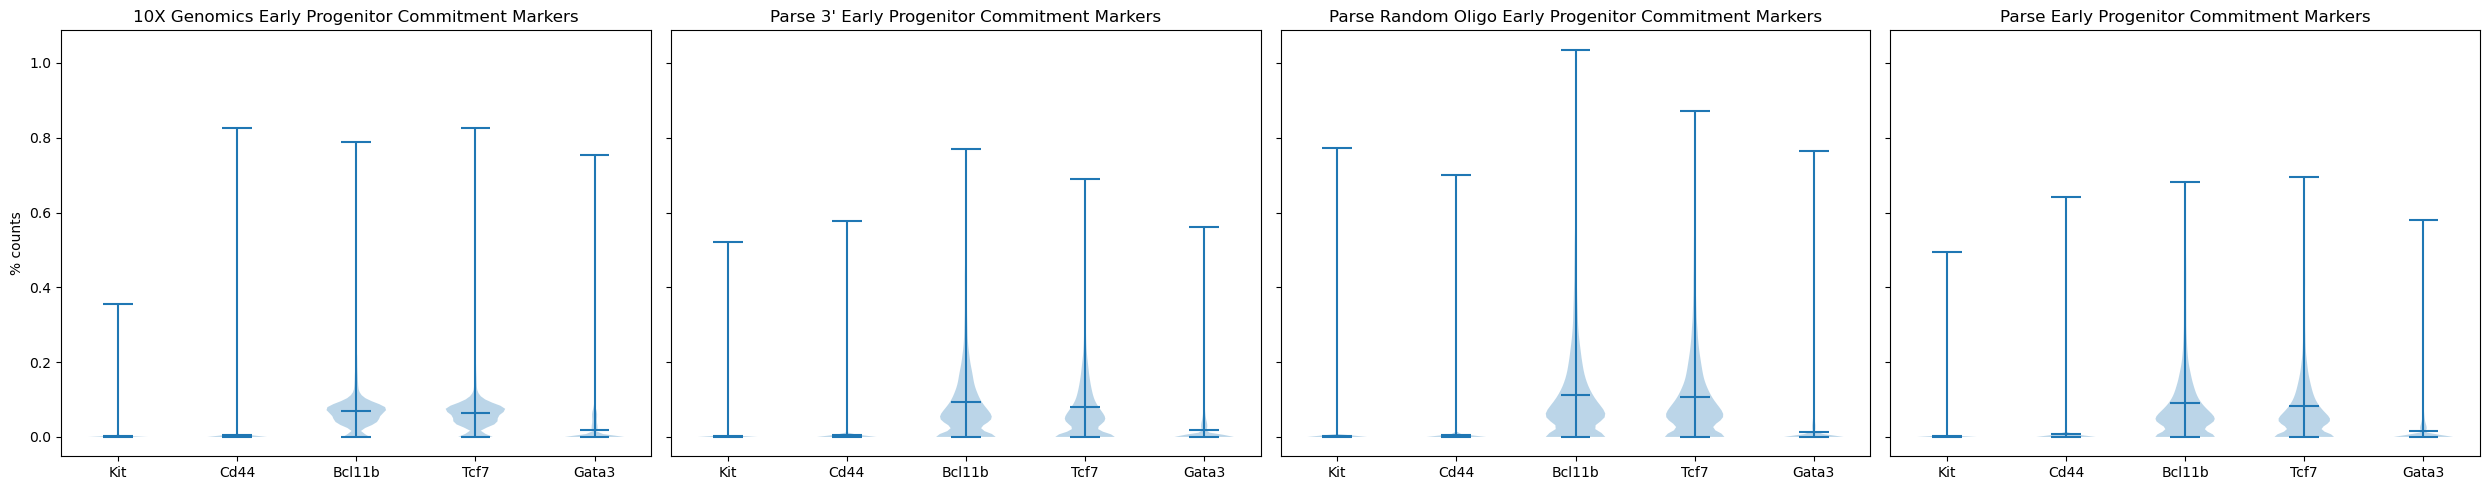

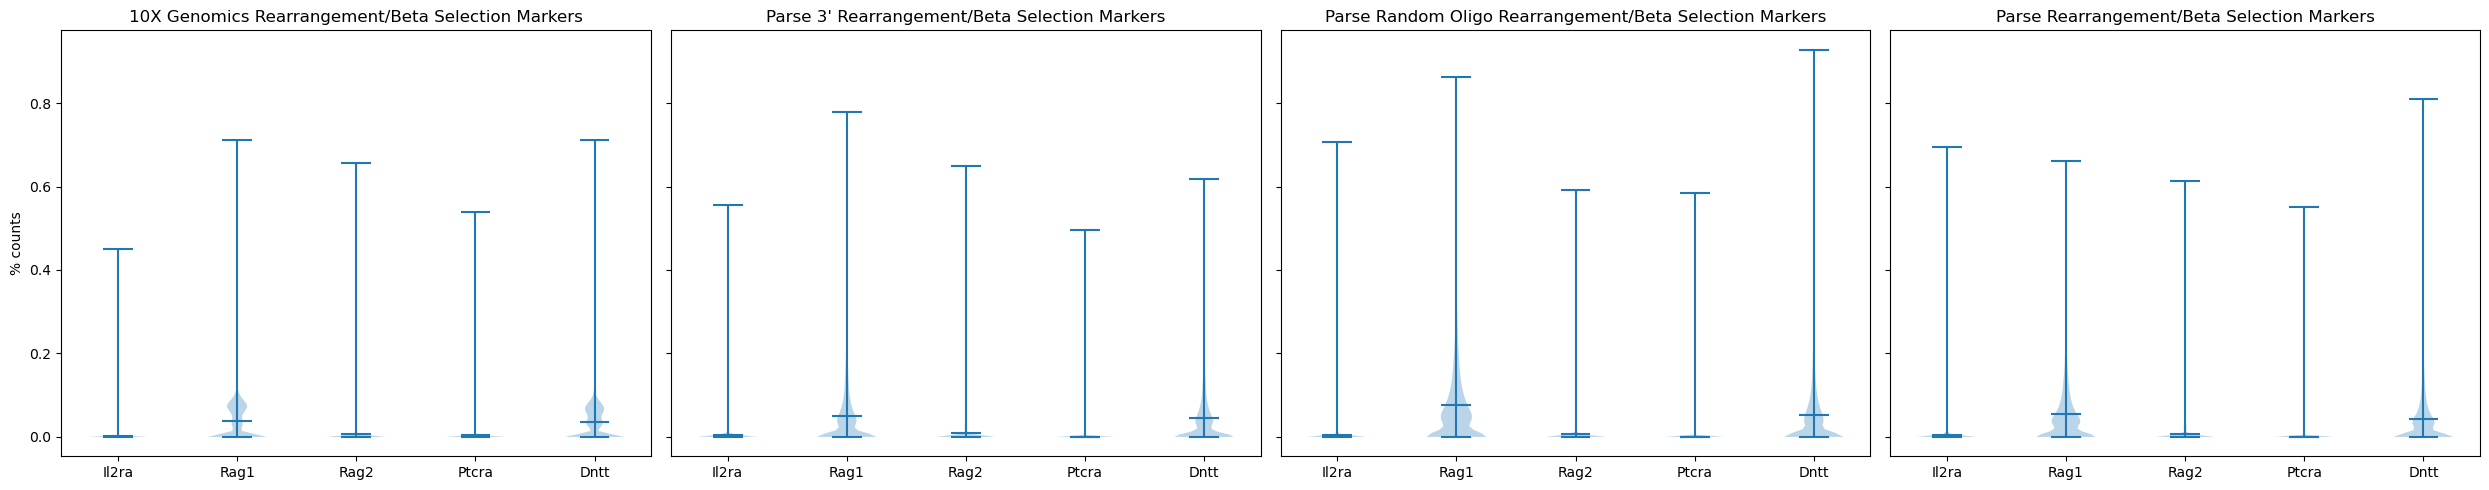

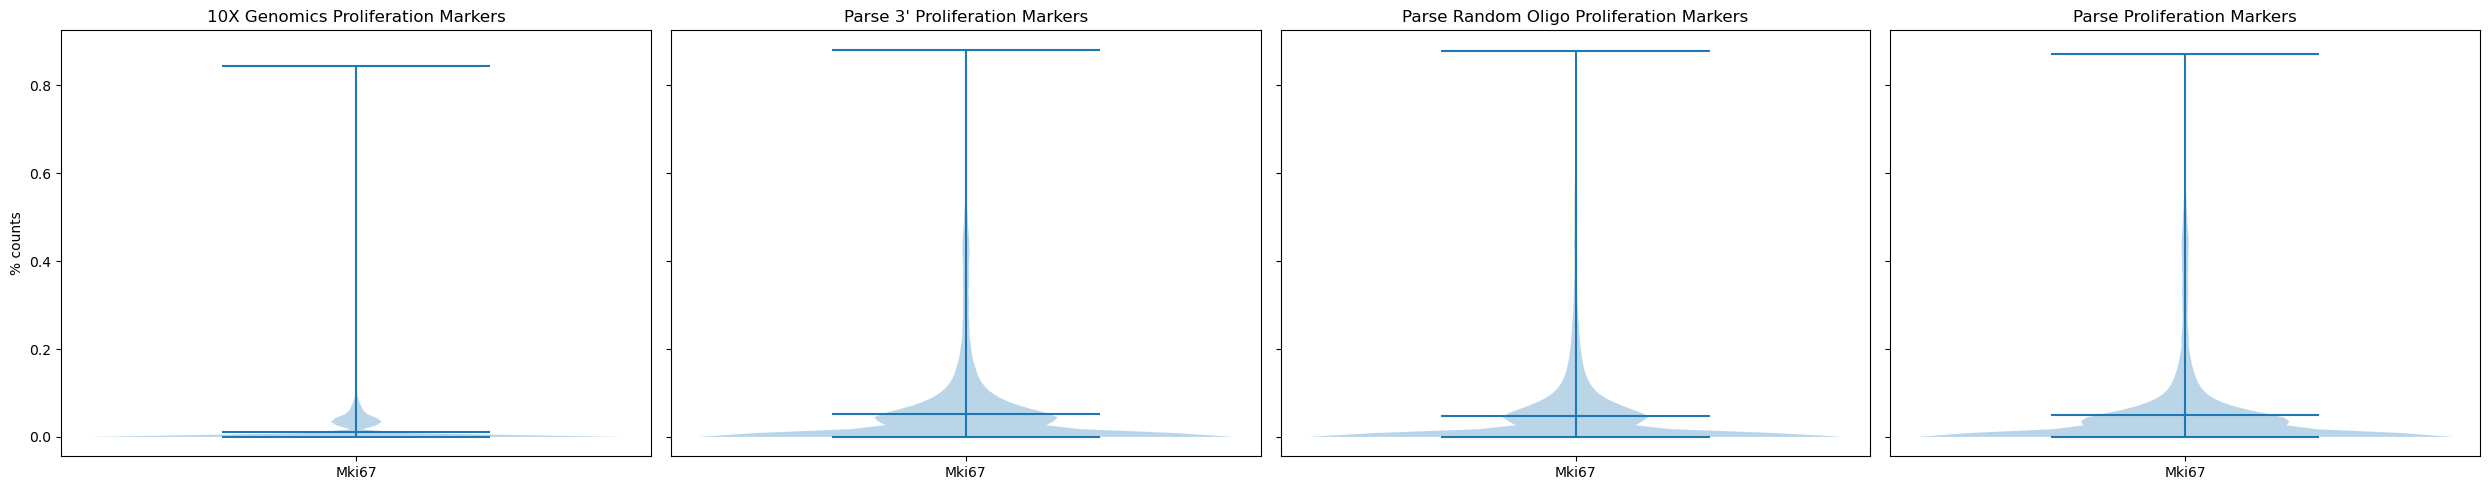

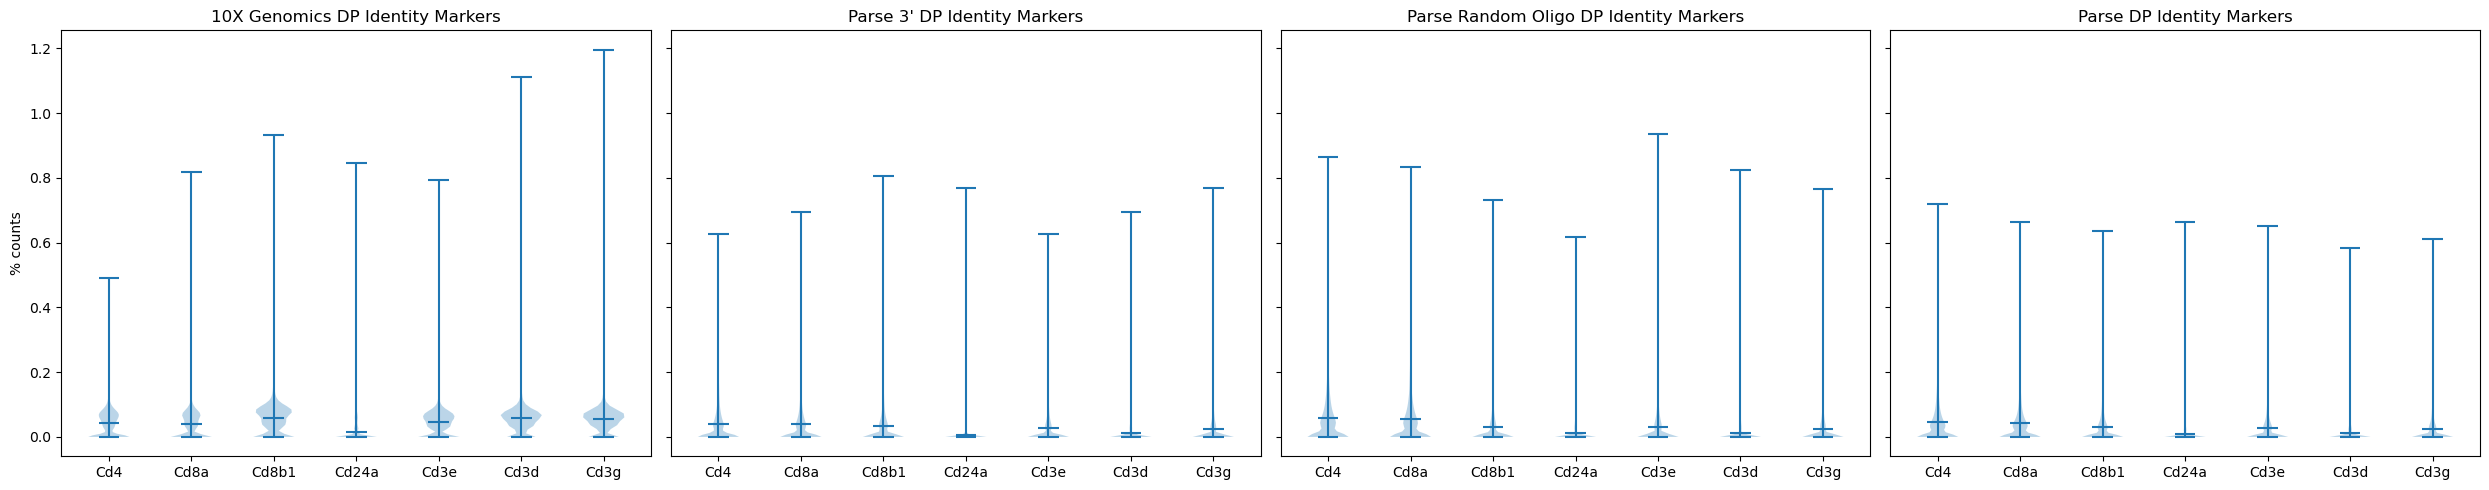

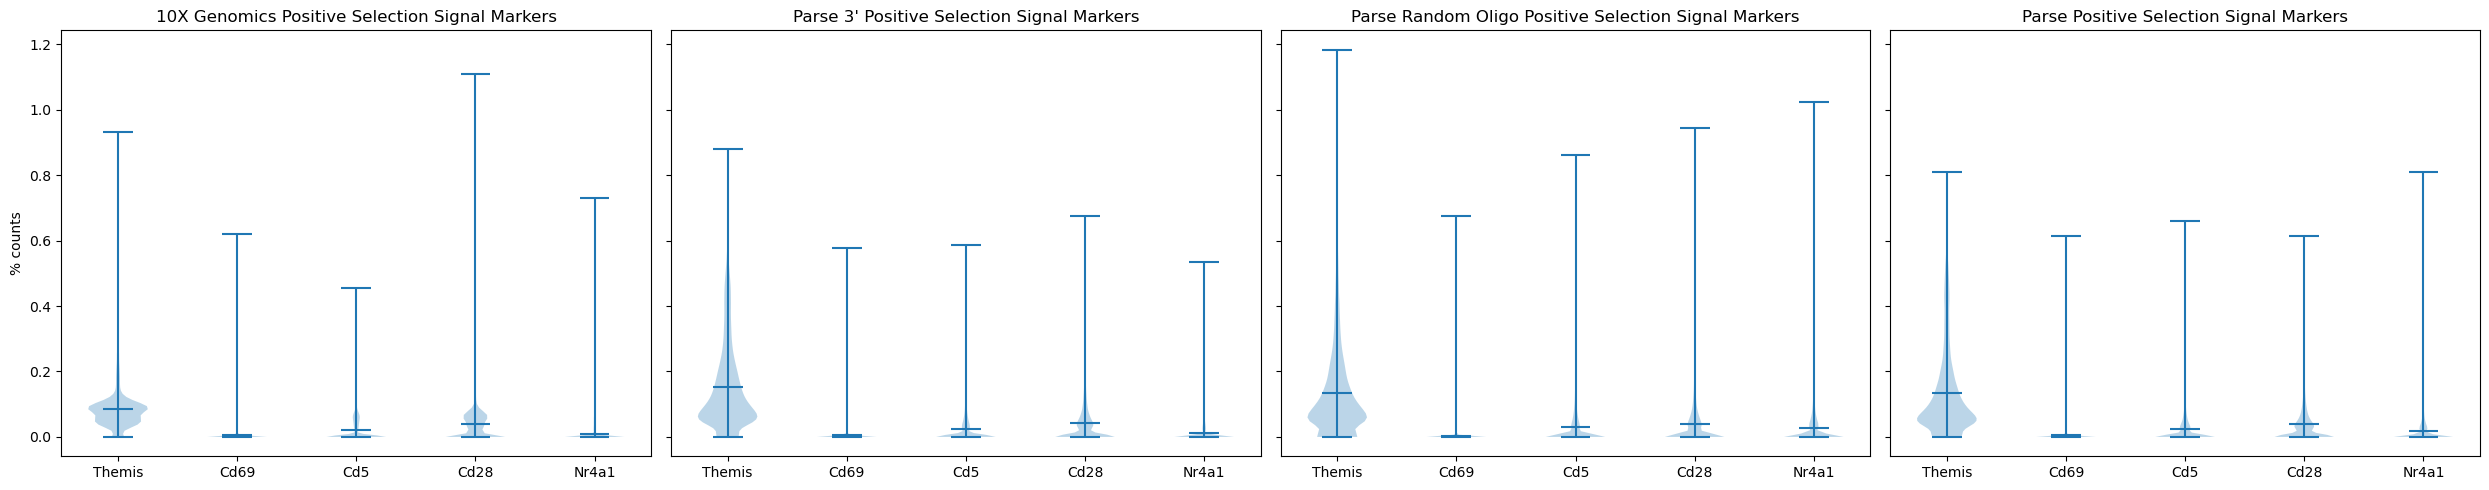

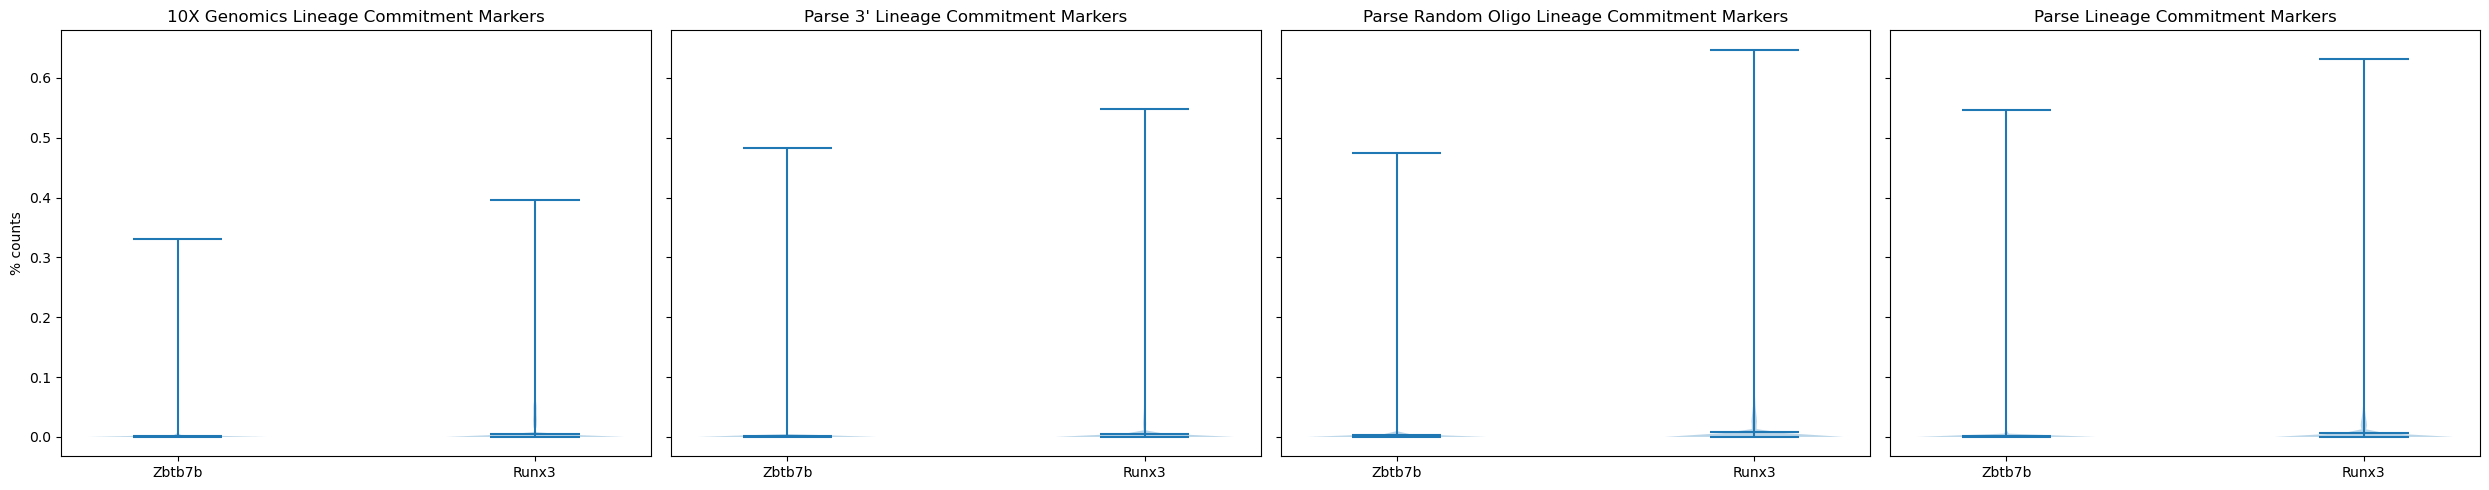

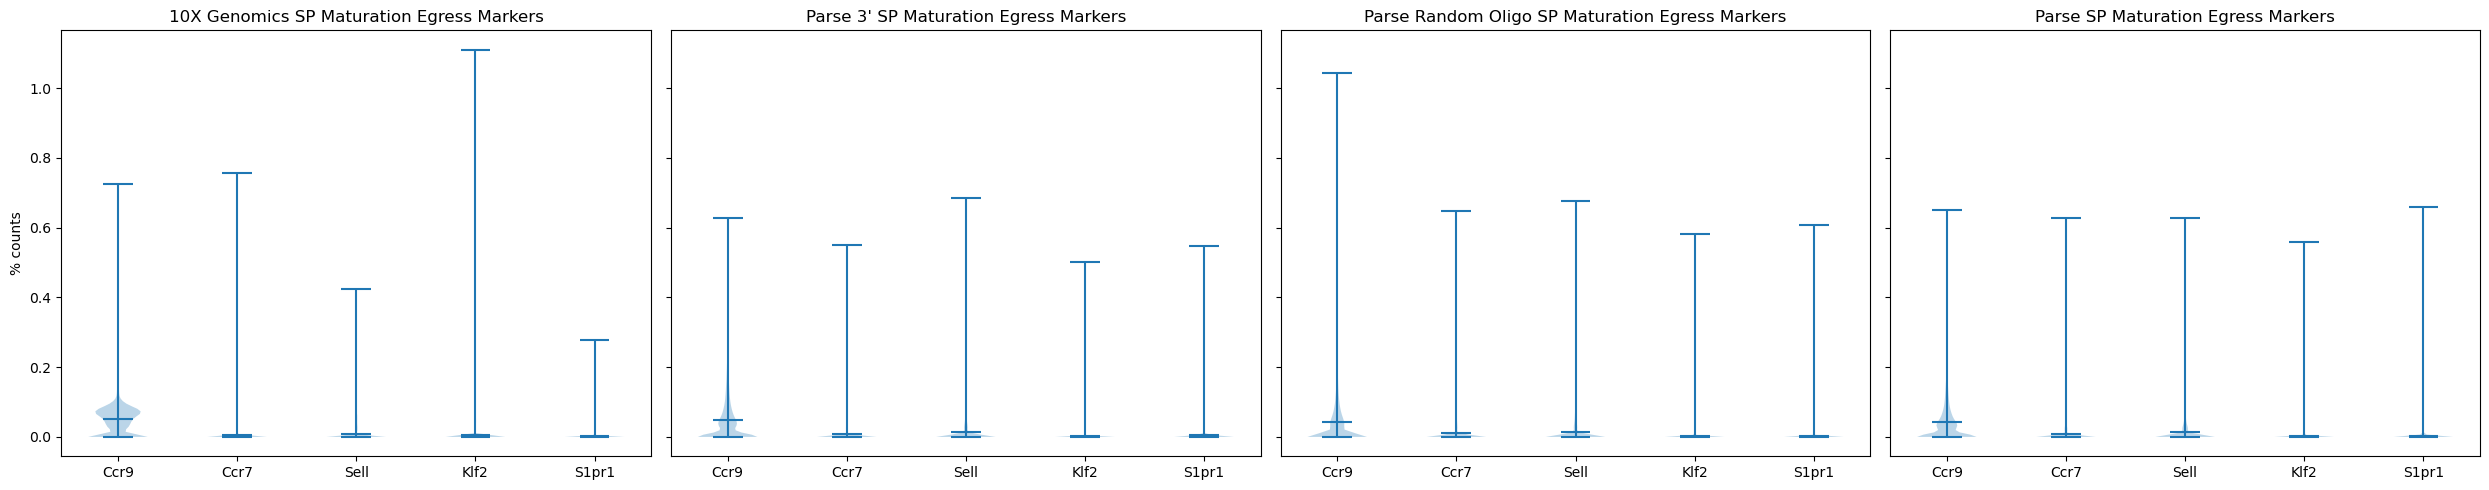

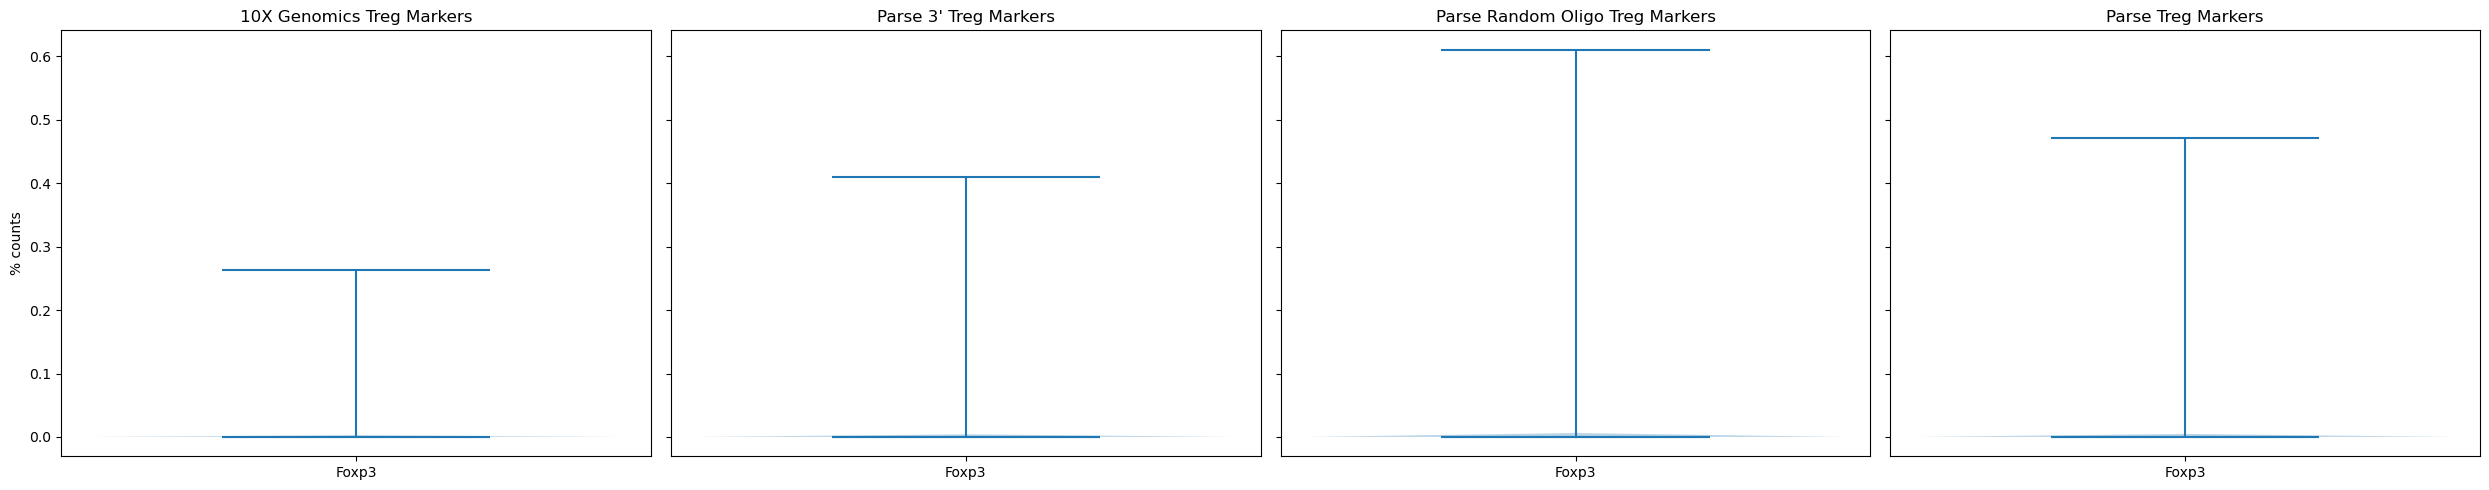

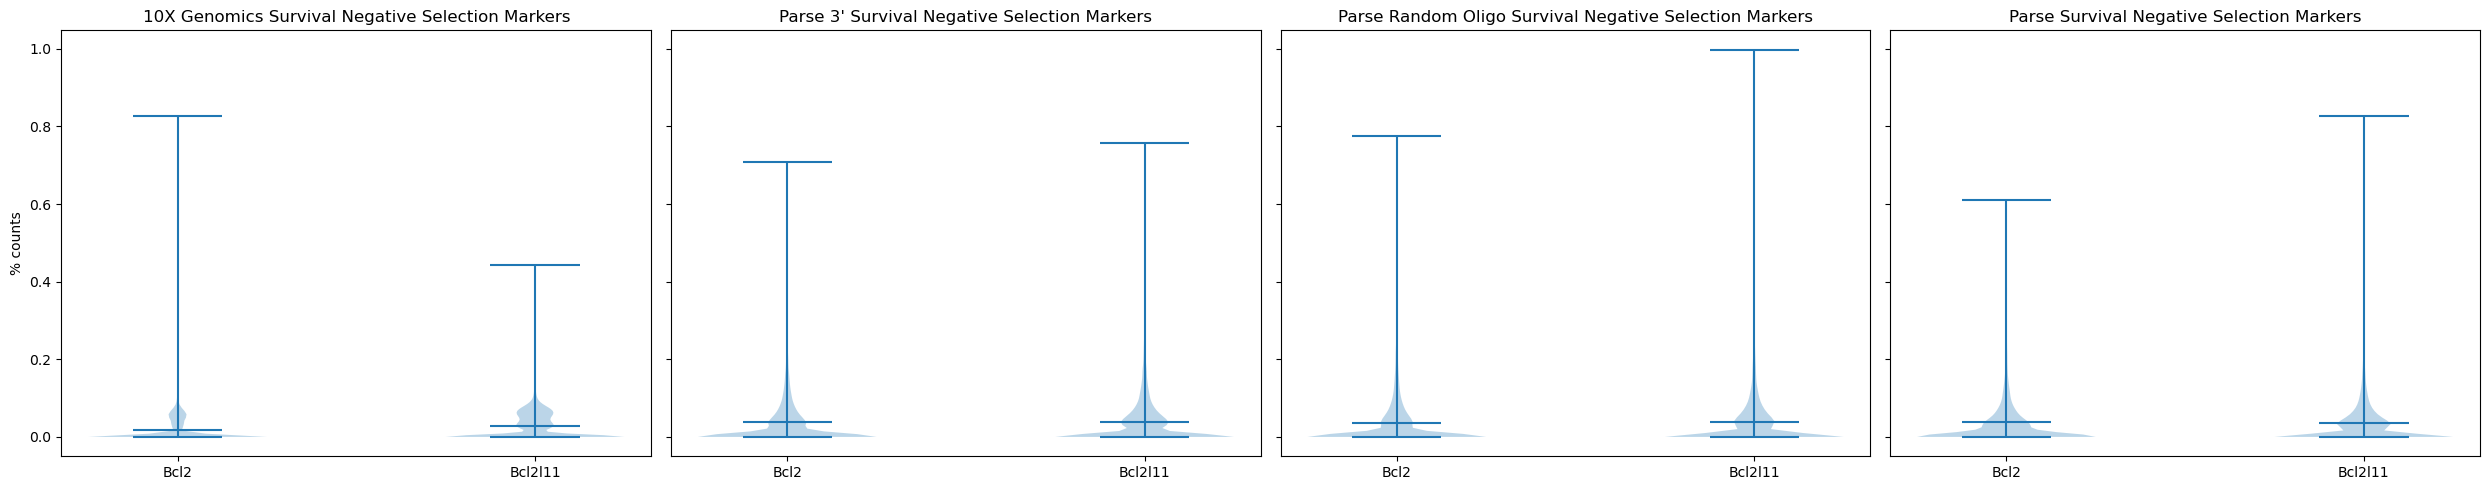

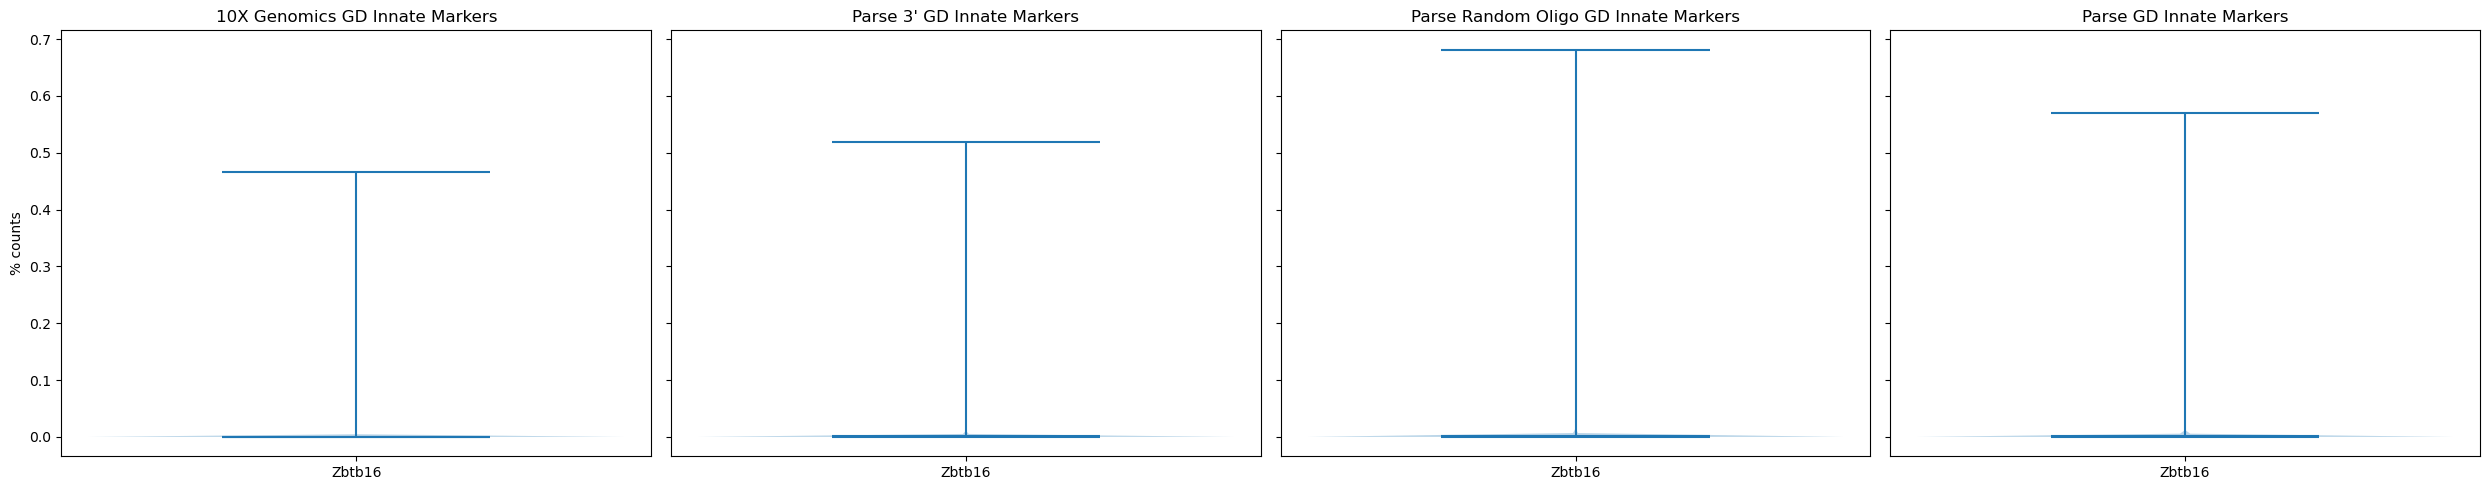

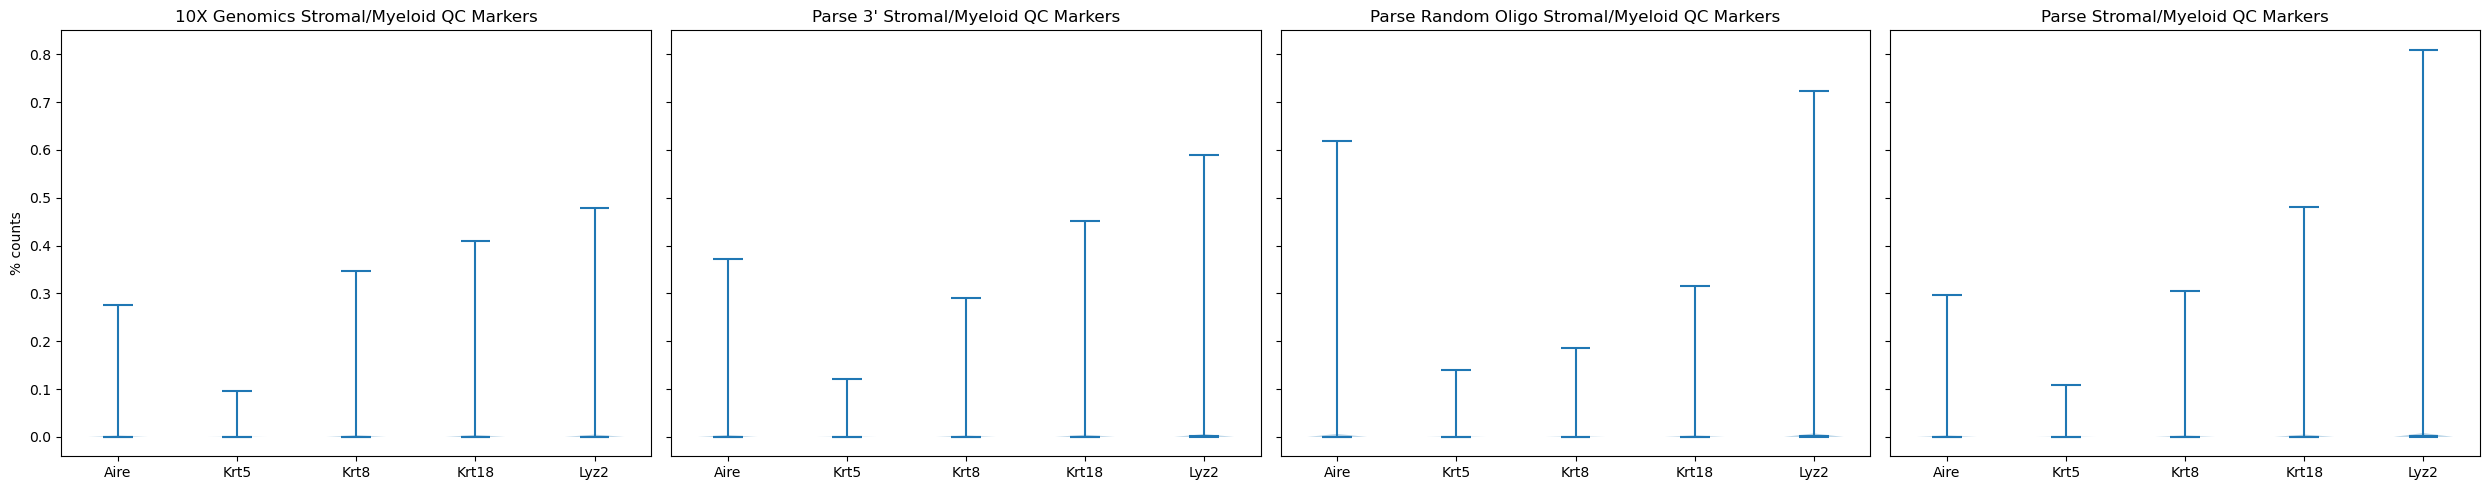

In [21]:
for marker_set_name in thymocyte_markers.keys():
    plotting.marker_genes(datasets, thymocyte_markers[marker_set_name], plot_title=marker_set_name + " Markers")

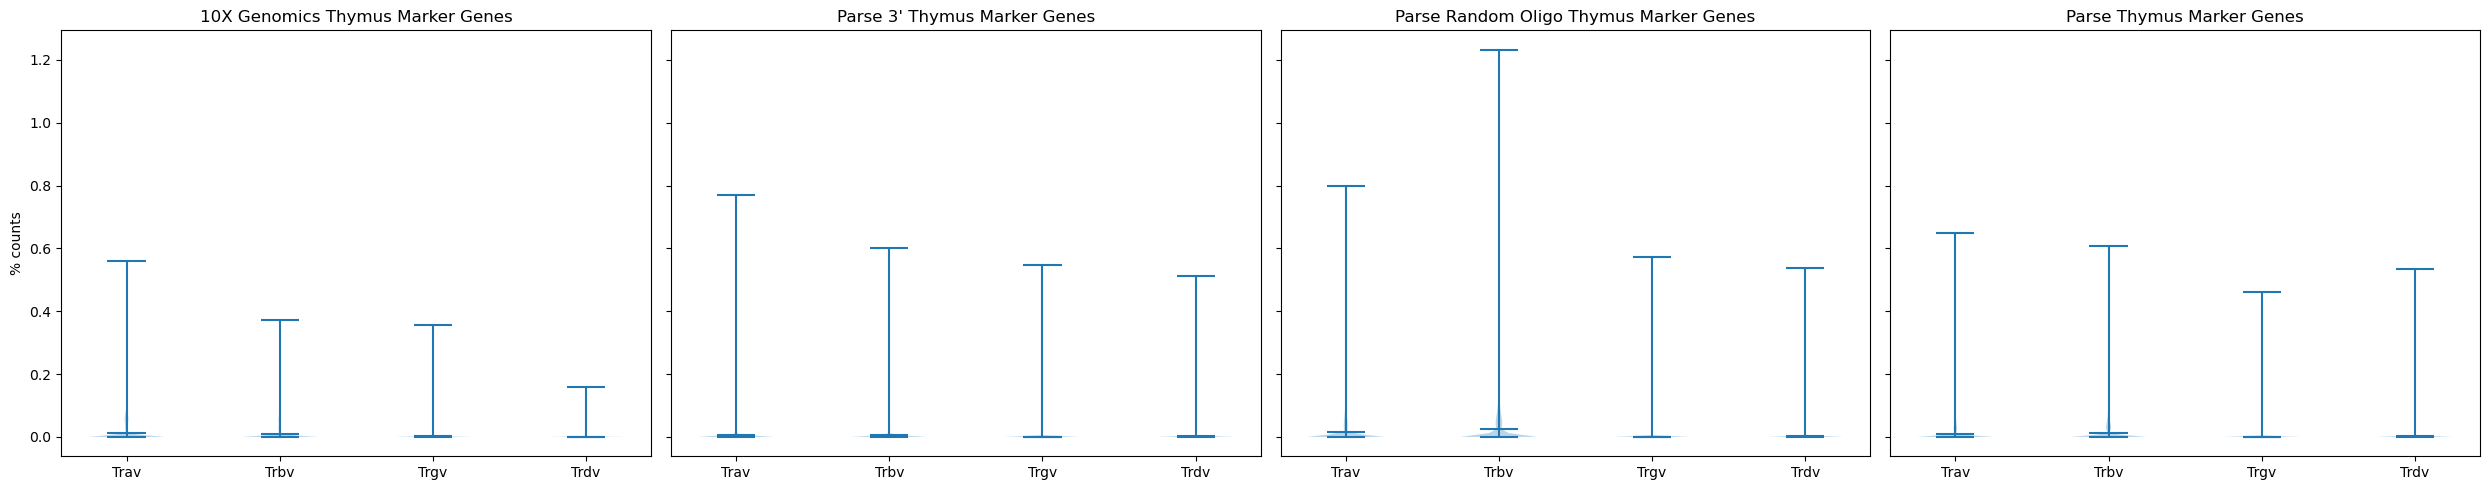

In [22]:
plotting.collapsed_marker_genes(datasets, tcr_loci_prefixes)

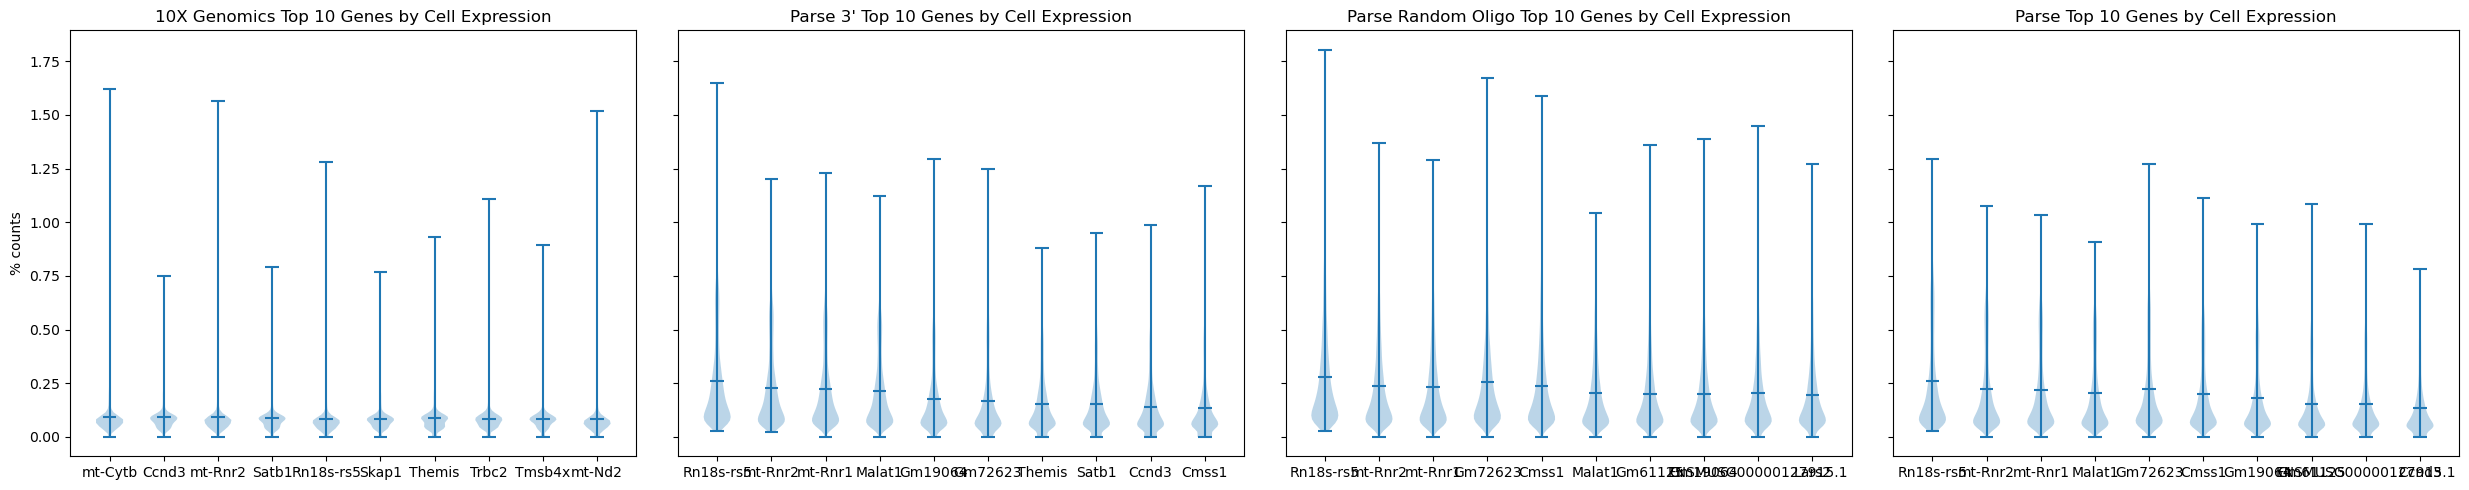

In [23]:
plotting.top_gene_cell_expression(datasets)

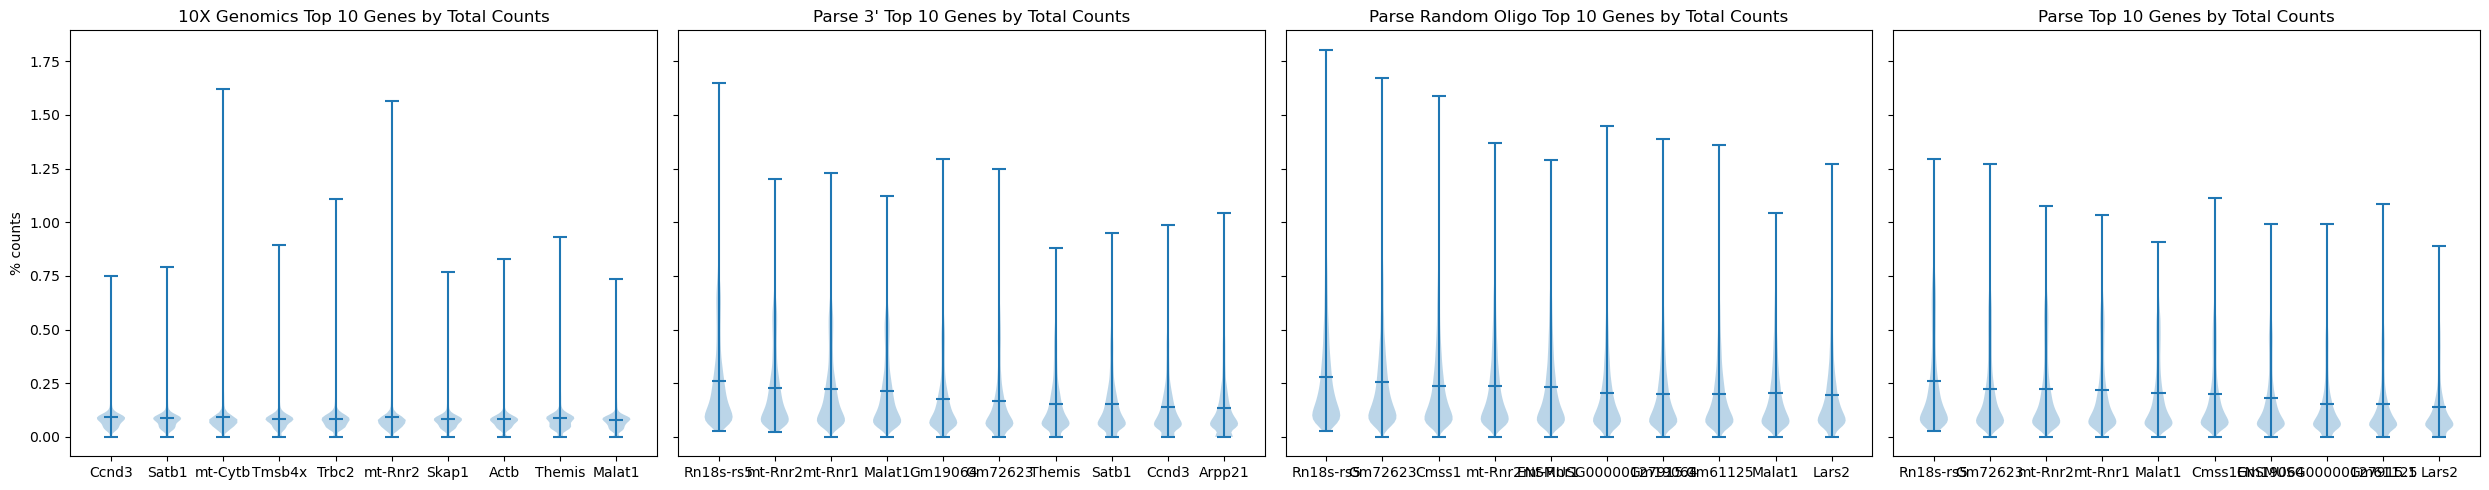

In [24]:
plotting.top_gene_counts(datasets)

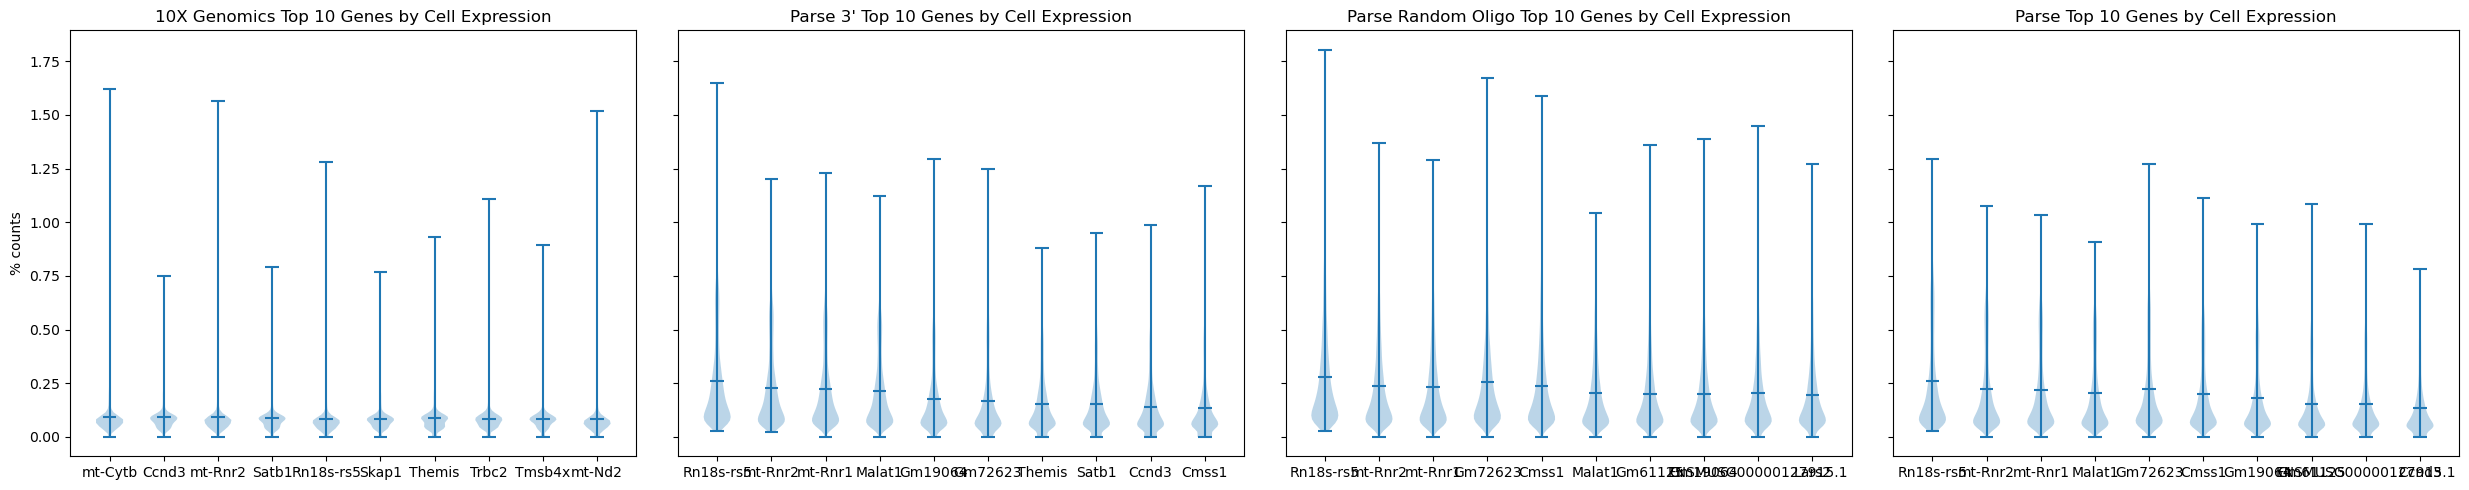

In [25]:
plotting.top_gene_cell_expression(datasets)

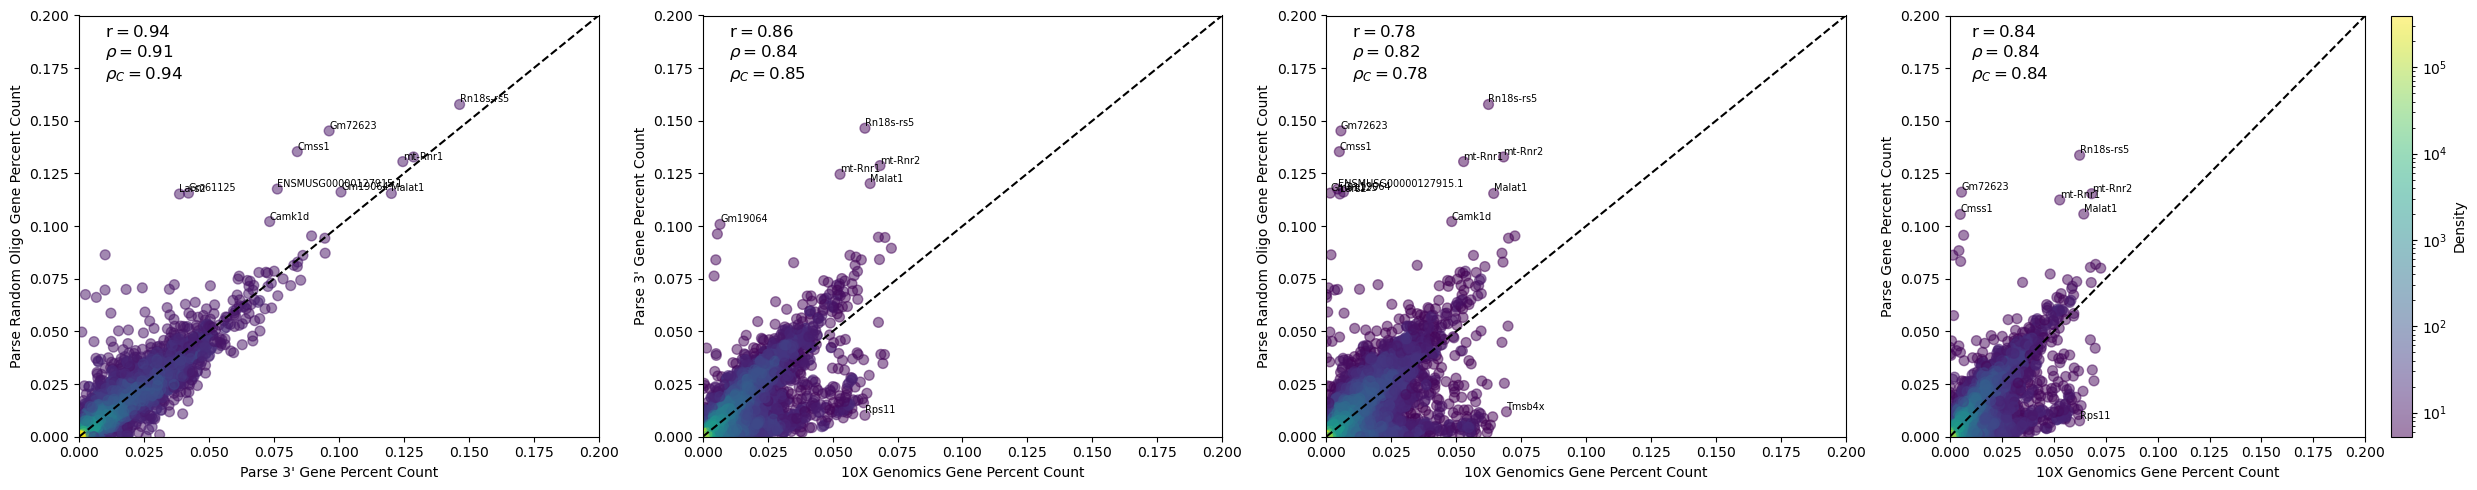

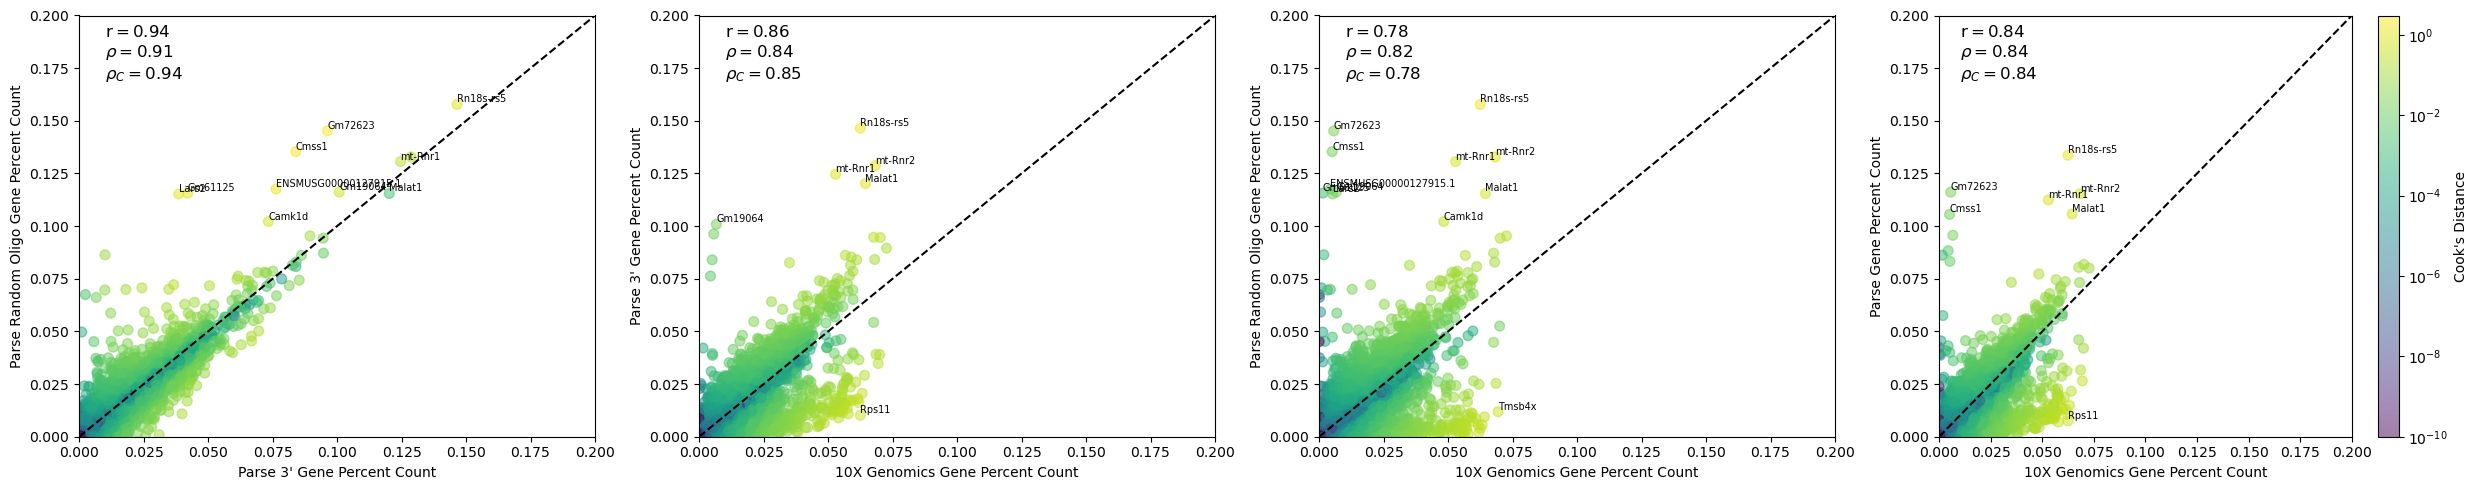

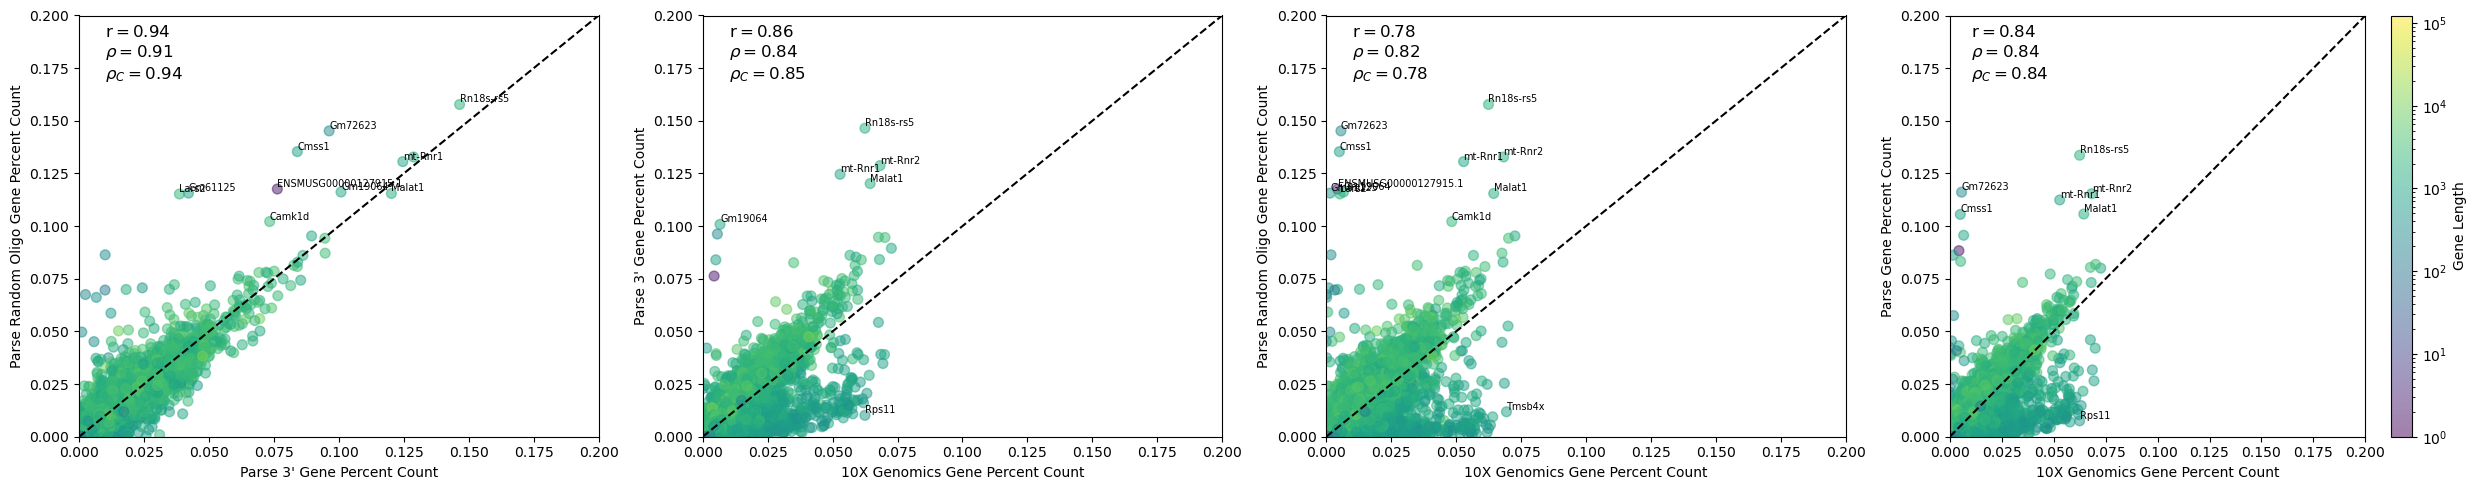

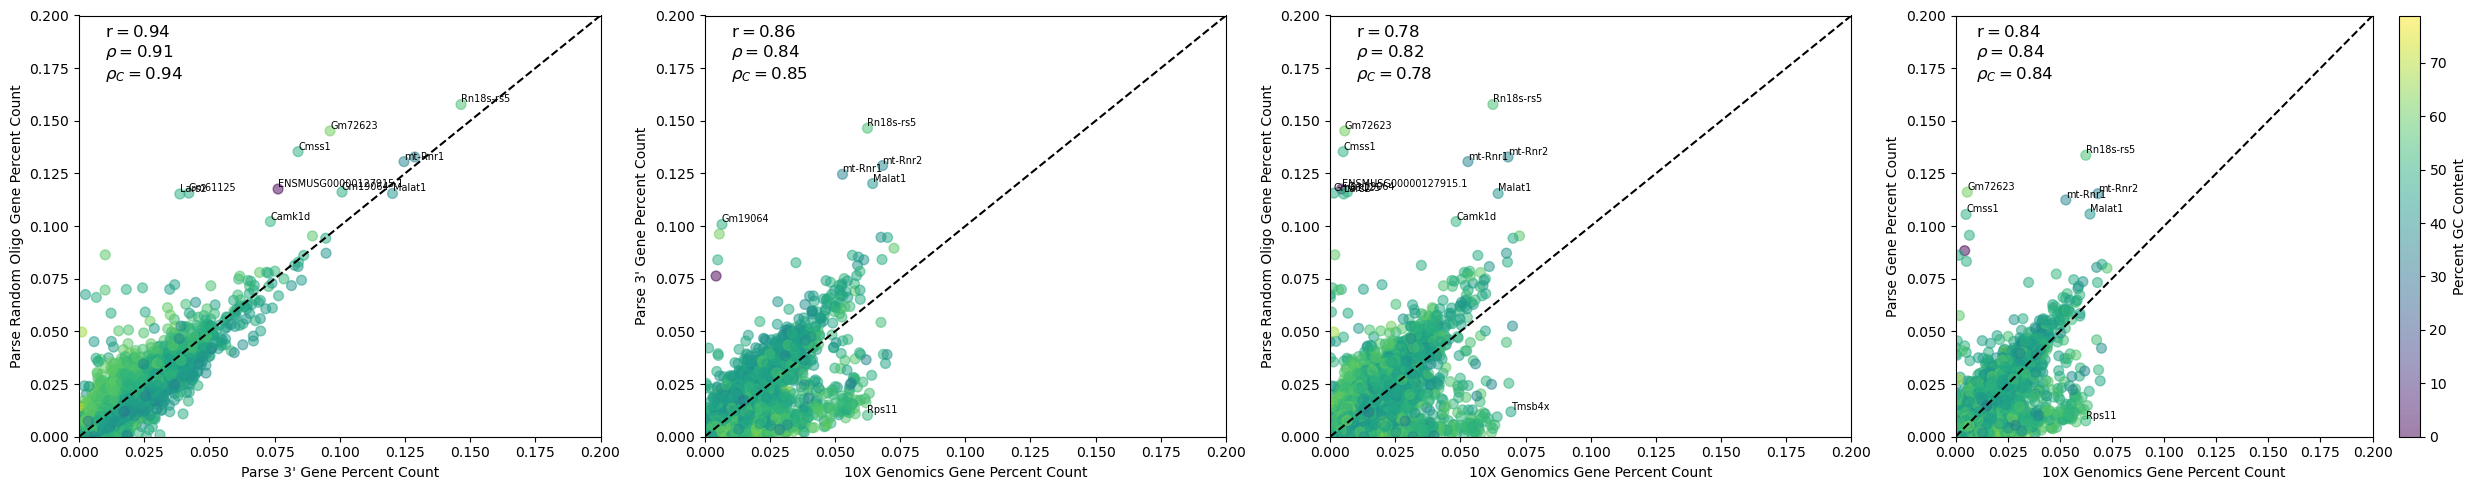

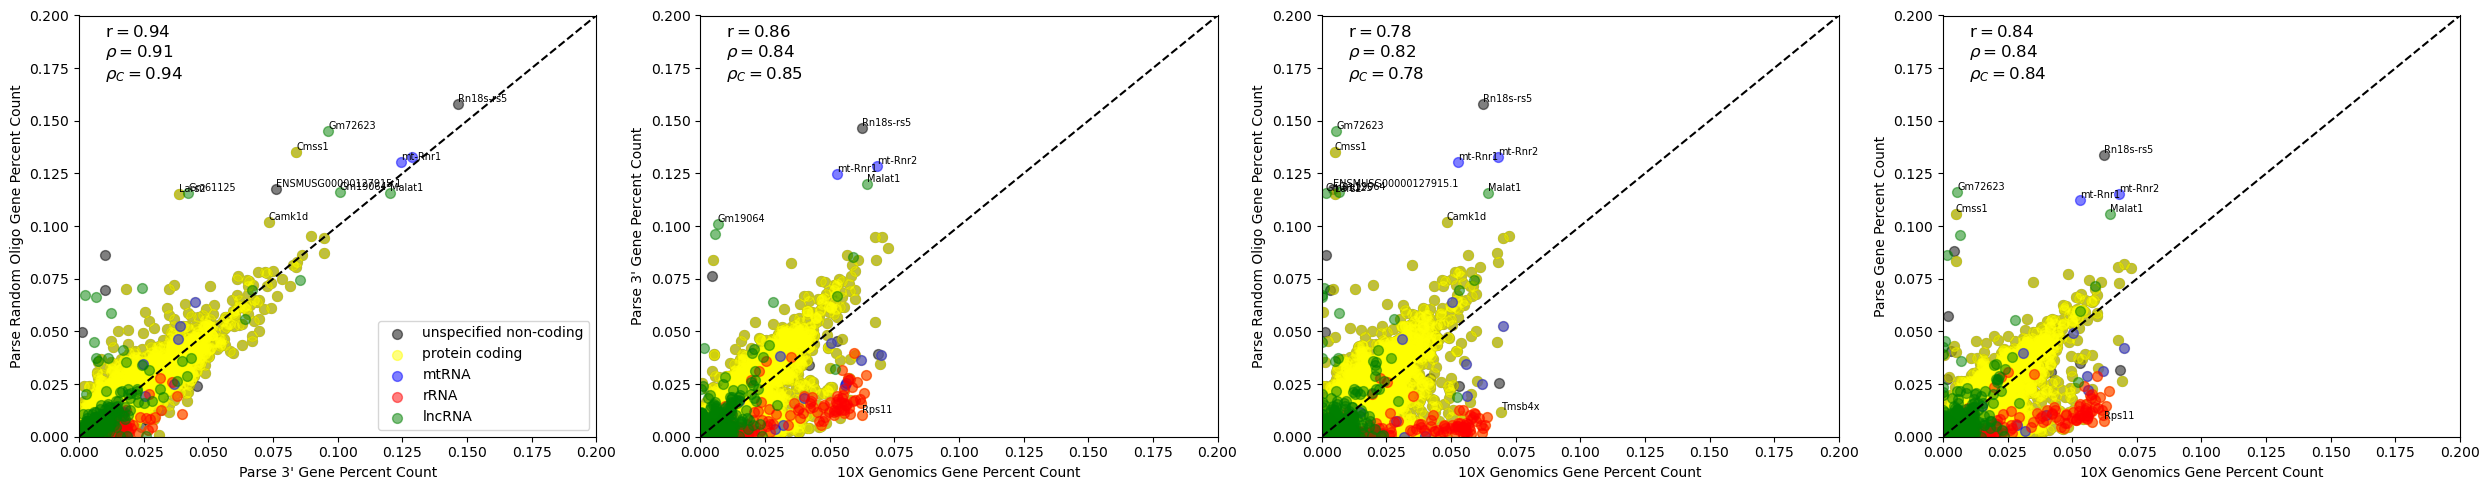

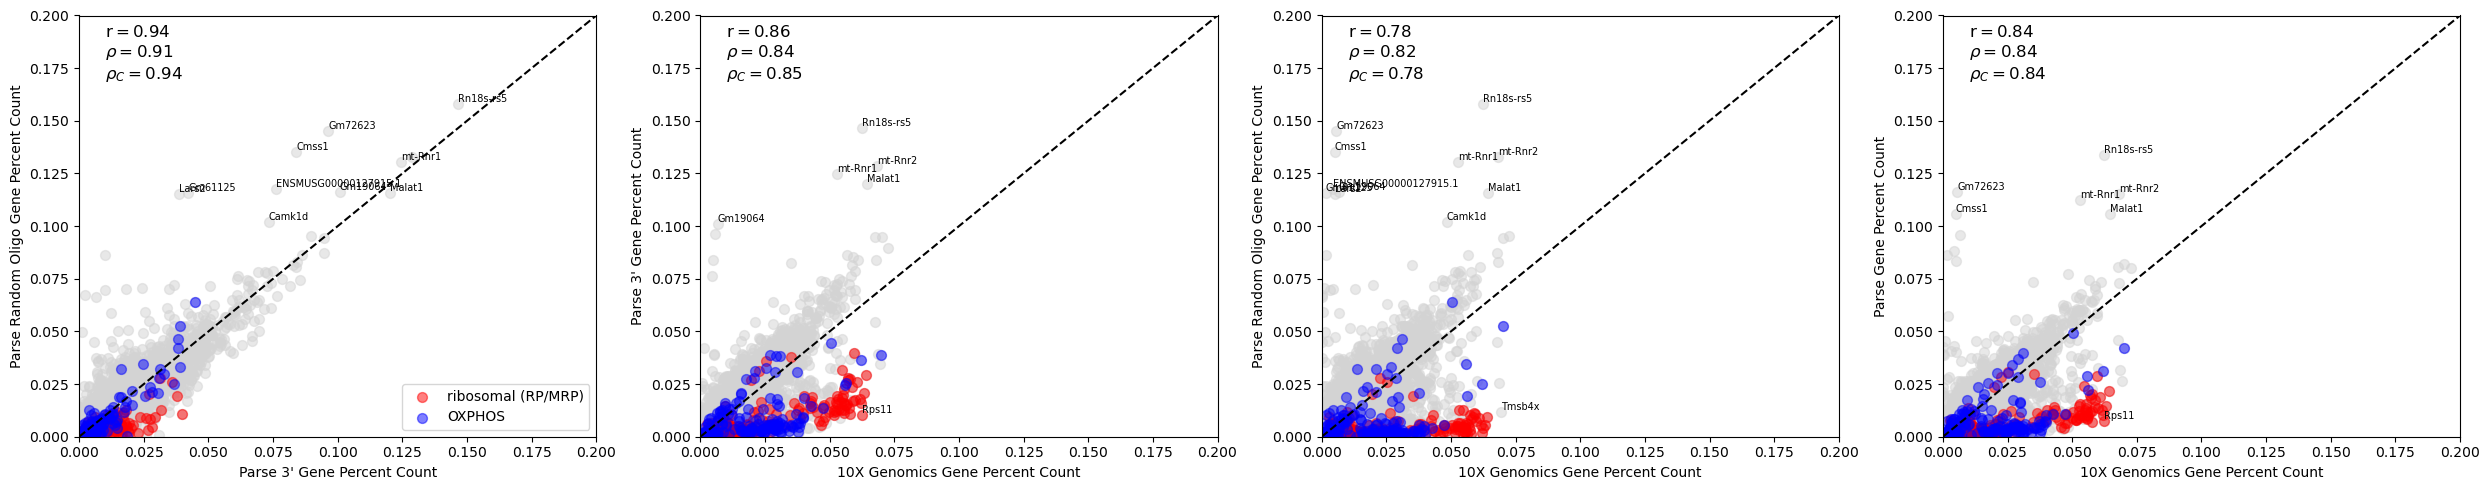

In [26]:
if LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 0.2)

In [27]:
if not LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 8)

In [28]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 1.5)

In [29]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 0.5)

In [30]:
if LOGCPM_TRANSFORM:
    lim = 0.2
else:
    lim = 1.2

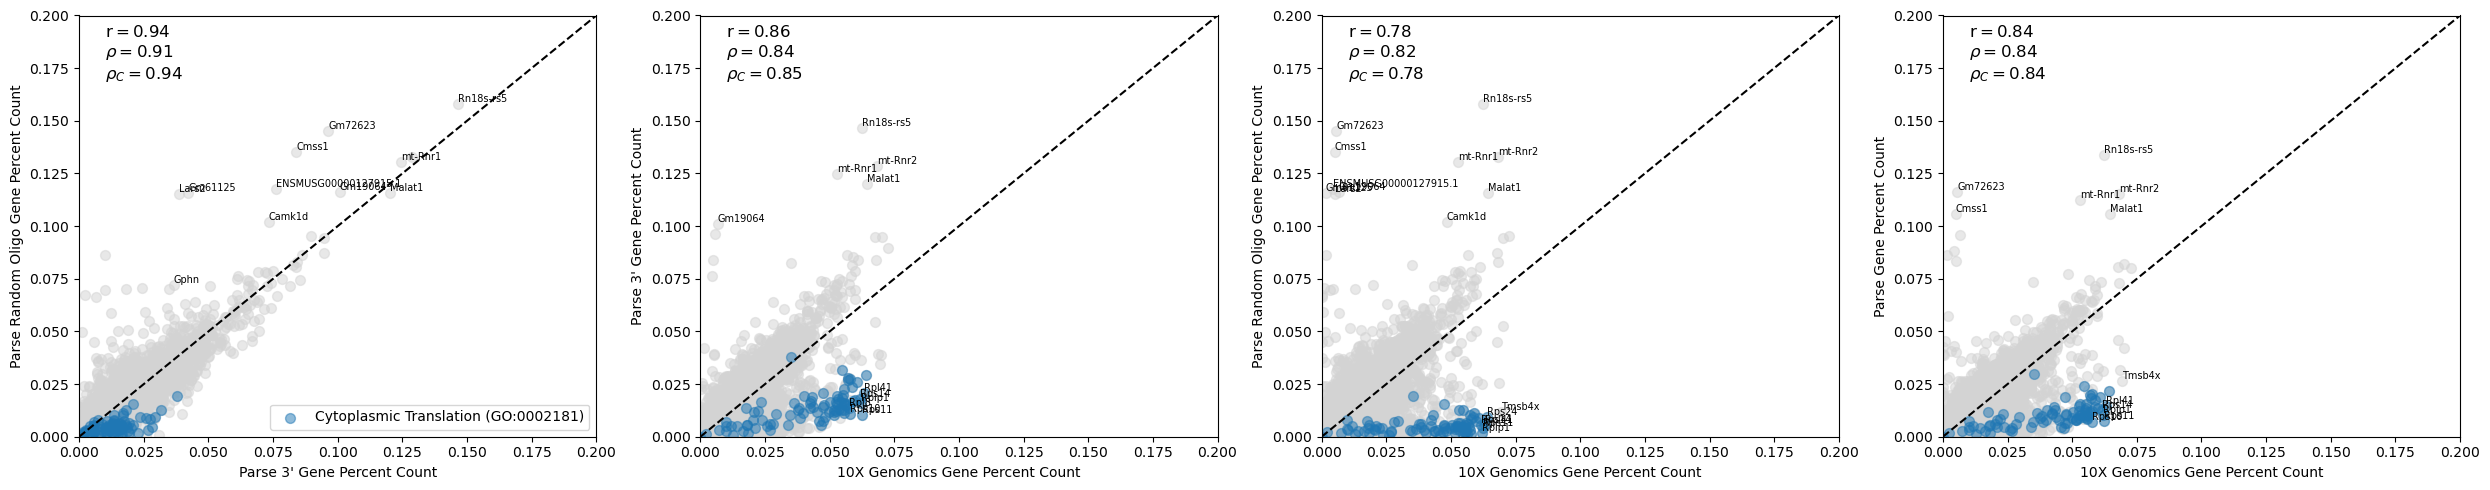

In [31]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Cytoplasmic Translation (GO:0002181)"]
)

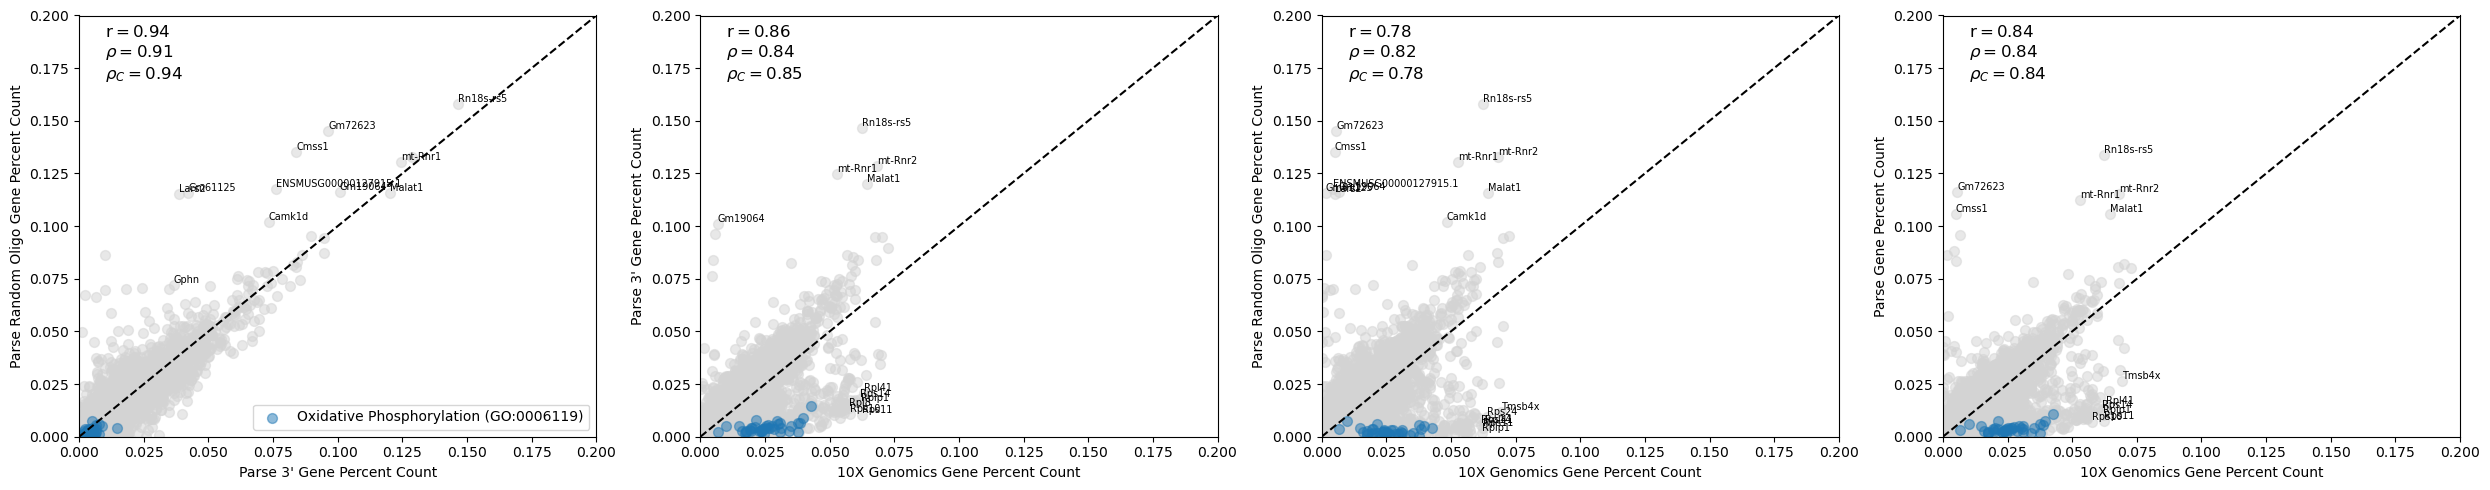

In [32]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Oxidative Phosphorylation (GO:0006119)"])

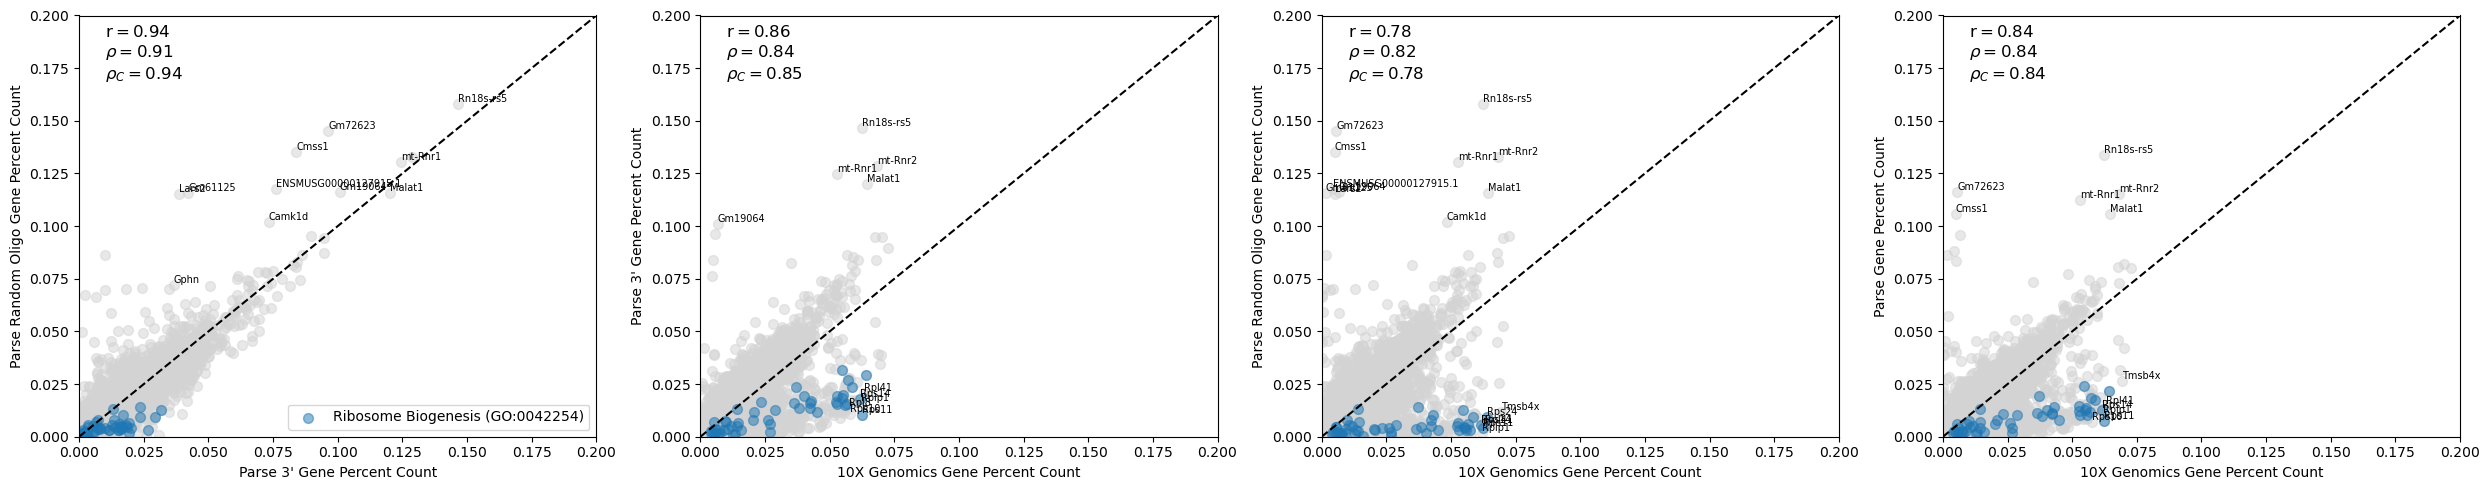

In [33]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Ribosome Biogenesis (GO:0042254)"])

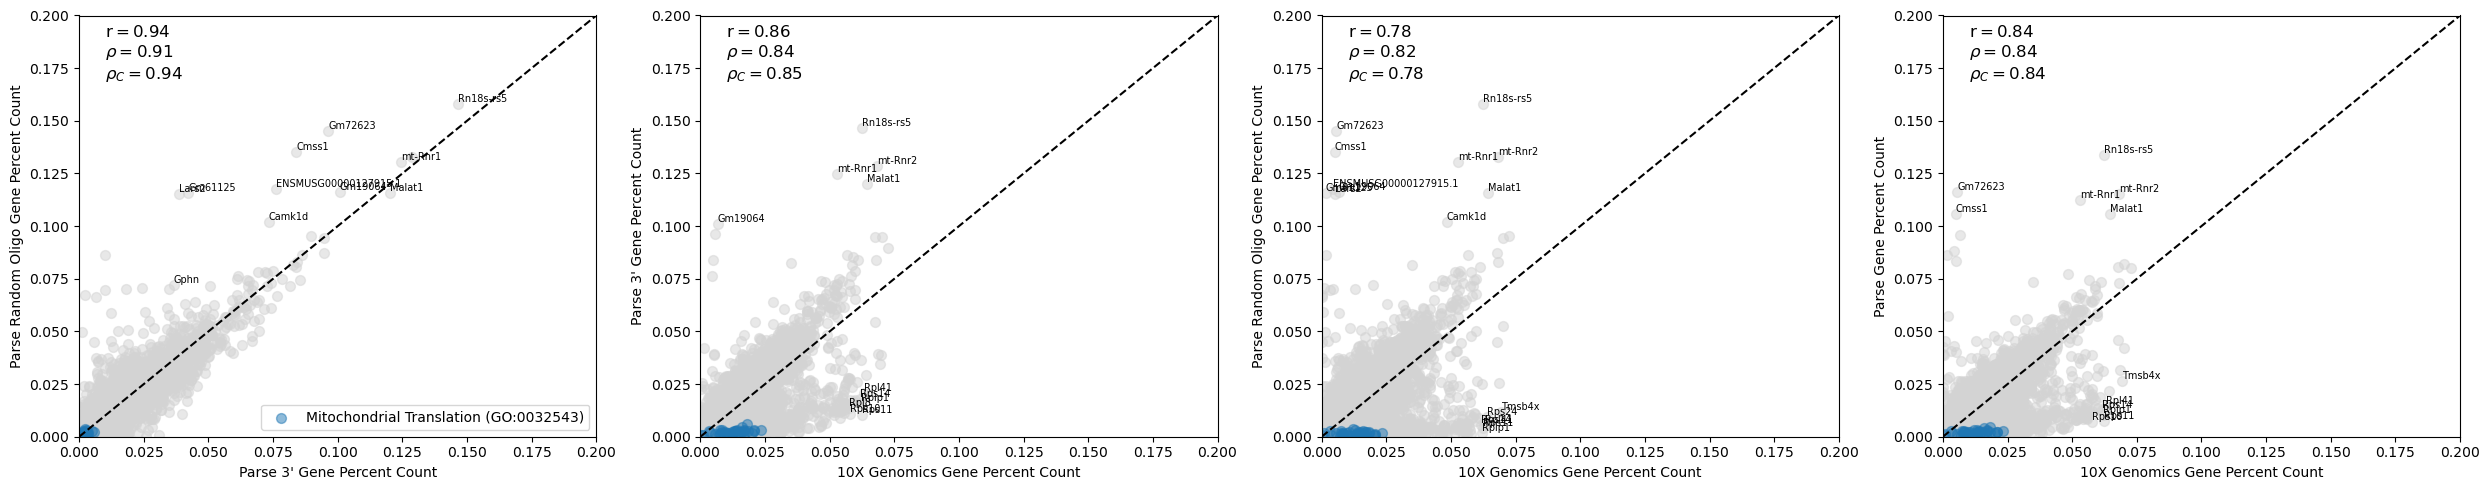

In [34]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Translation (GO:0032543)"])

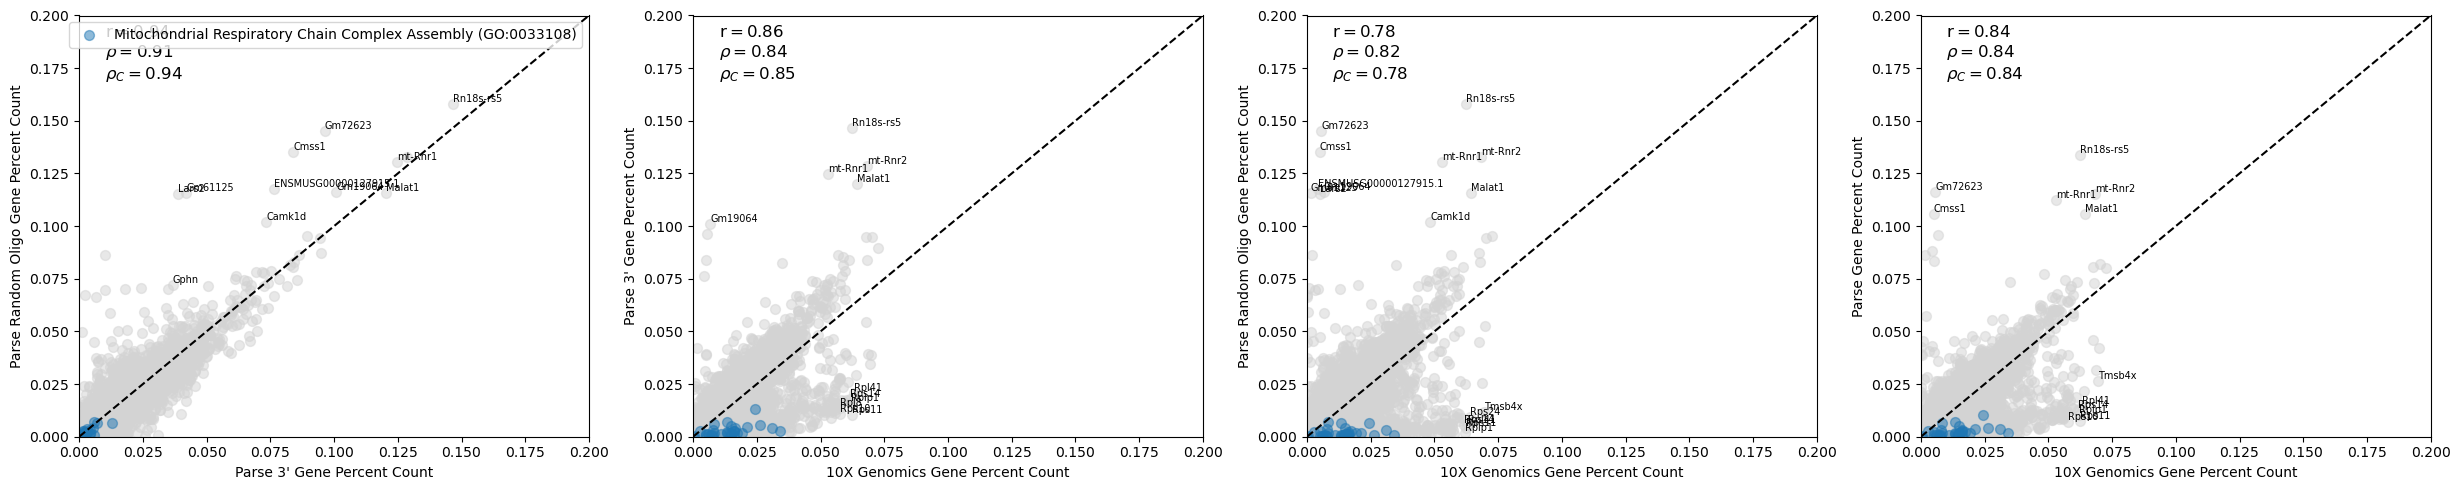

In [35]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)"])

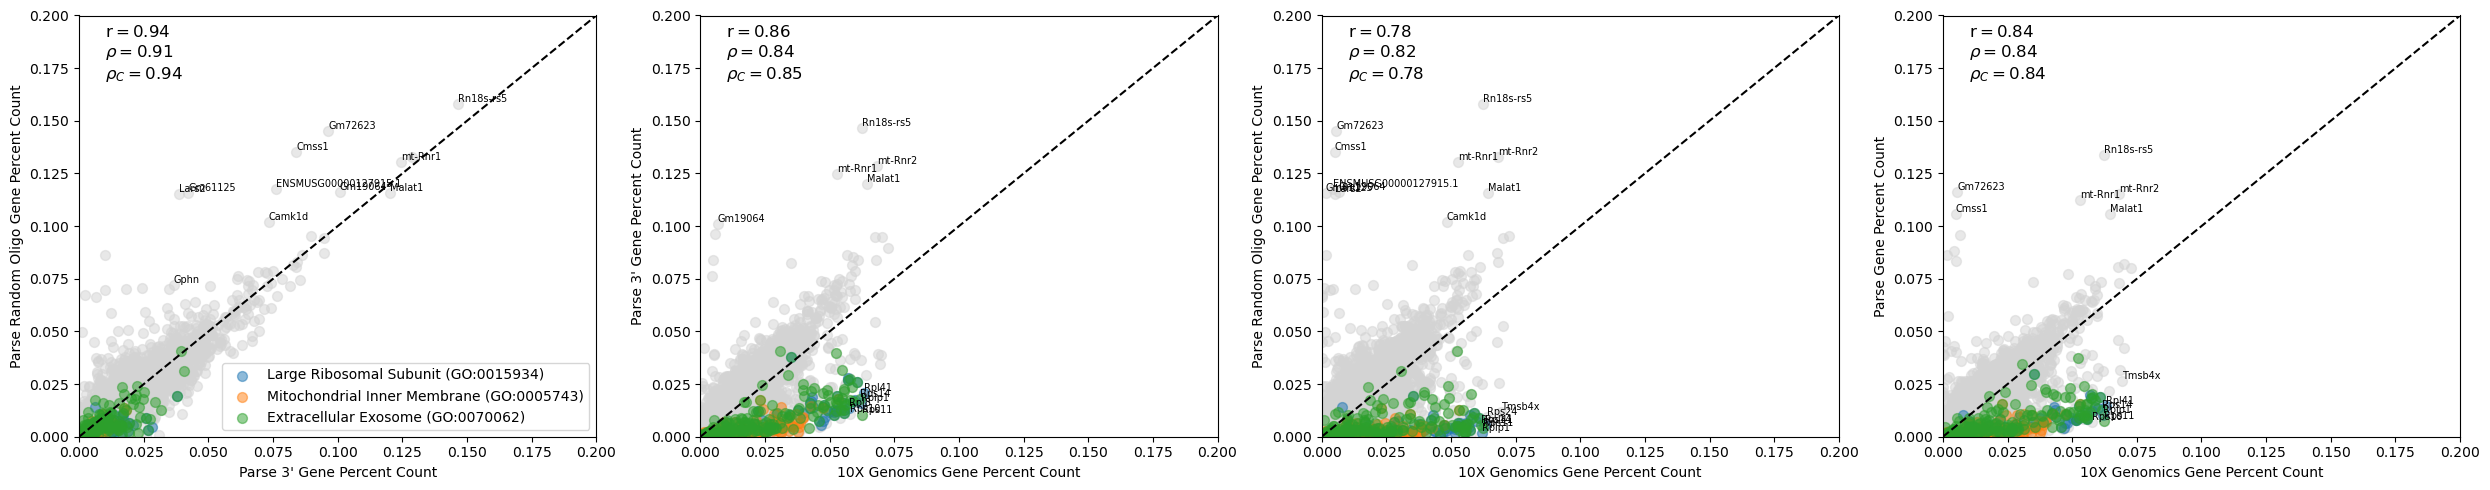

In [36]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Extracellular Exosome (GO:0070062)", "Large Ribosomal Subunit (GO:0015934)", "Mitochondrial Inner Membrane (GO:0005743)"])

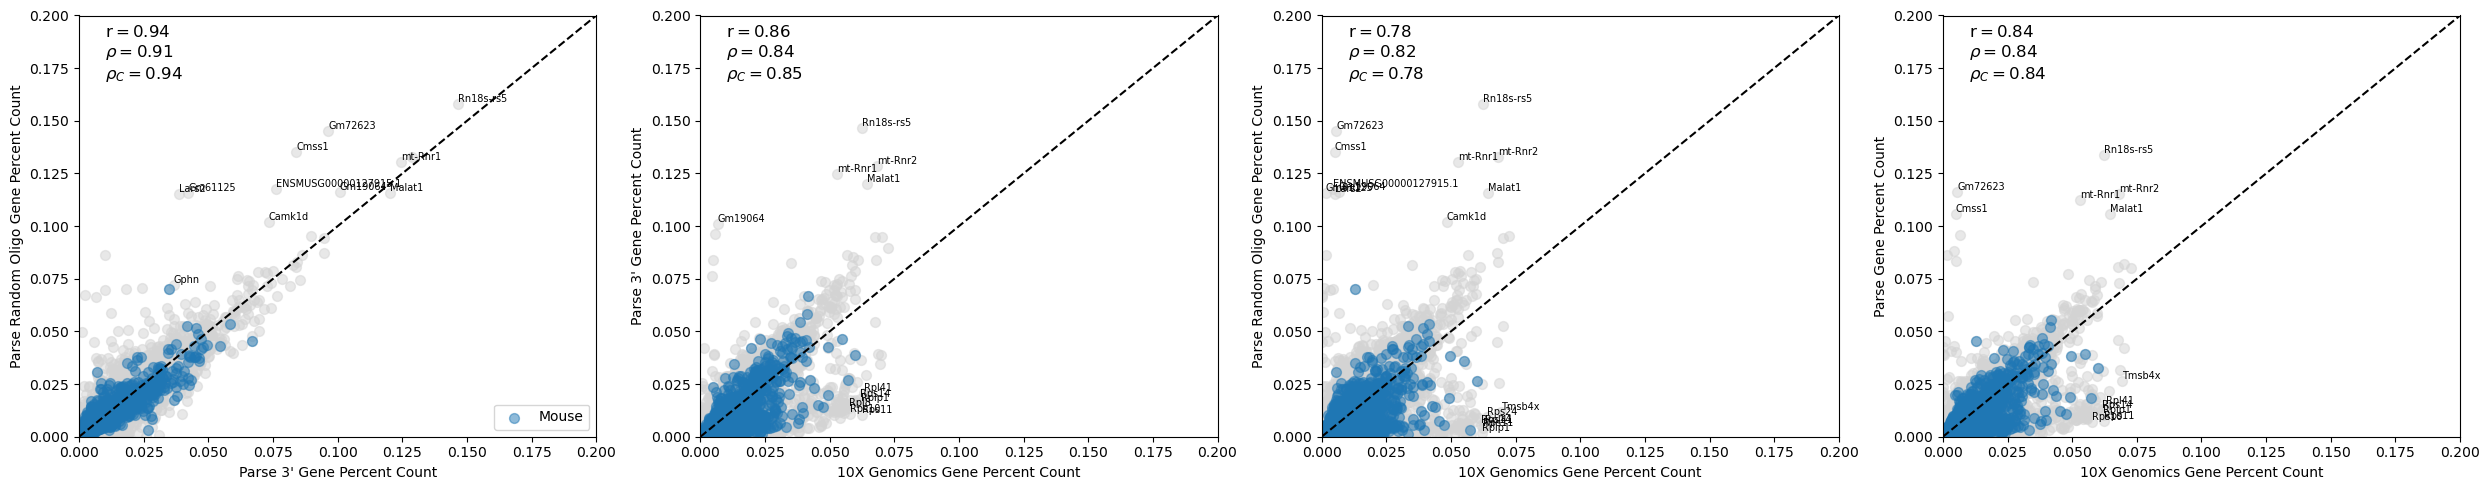

In [37]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
    gene_sets=["Housekeeping"],
    terms=["Mouse"])

In [38]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)